In [ ]:
import os
import sys

sys.stderr = open(os.devnull, "w")

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import psycopg2
from datetime import timedelta
from dateutil.relativedelta import relativedelta
from sklearn.utils import resample
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

warnings.filterwarnings('ignore', category=FutureWarning)

np.random.seed(42)

In [2]:
def calculate_prediction_intervals(y_test, gb_forecast, confidence_level=0.95, n_bootstrap=1000):
    """
    Calculate prediction intervals using bootstrapping.

    Parameters:
    - y_test: pandas.Series, actual test values
    - forecast: pandas.Series, forecasted values
    - confidence_level: float, confidence level for prediction interval (e.g., 0.95 for 95%)
    - n_bootstrap: int, number of bootstrap samples

    Returns:
    - lower_bound: pandas.Series, lower bound of prediction interval
    - upper_bound: pandas.Series, upper bound of prediction interval
    """
    # Step 3: Calculate residuals
    residuals = y_test - gb_forecast

    # Step 4: Bootstrapping
    bootstrap_samples = []
    for _ in range(n_bootstrap):
        sample_residuals = np.random.choice(residuals, size=len(residuals), replace=True)
        bootstrap_forecast = gb_forecast + sample_residuals
        bootstrap_samples.append(bootstrap_forecast)

    # Step 6: Calculate prediction intervals
    lower_percentile = (1 - confidence_level) / 2 * 100
    upper_percentile = (1 + confidence_level) / 2 * 100
    lower_bound = pd.Series(np.percentile(bootstrap_samples, lower_percentile, axis=0), index=y_test.index)
    forecast = pd.Series(np.percentile(bootstrap_samples, 50, axis=0), index=y_test.index)
    upper_bound = pd.Series(np.percentile(bootstrap_samples, upper_percentile, axis=0), index=y_test.index)

    return lower_bound, forecast, upper_bound

In [3]:
def calculate_oot_prediction_intervals(df, X_oot, oot_gb, target_column='price_total_agg', confidence_level=0.95, n_bootstrap=1000):
    """
    Calculate OOT prediction intervals for out-of-time data.

    Parameters:
    - df: pandas.DataFrame, training data containing features and target
    - X_oot: pandas.DataFrame, out-of-time features
    - oot_gb: OOT model
    - target_column: str, name of the target column in df (default: 'price_total_agg')
    - n_bootstrap: int, number of bootstrap samples (default: 1000)
    - confidence_level: float, confidence level for prediction interval (default: 0.95)

    Returns:
    - oot_gb_forecast_lower: pandas.Series, lower bound of prediction interval
    - oot_gb_forecast: pandas.Series, median forecast
    - oot_gb_forecast_upper: pandas.Series, upper bound of prediction interval
    """
    # Calculate percentiles based on confidence level
    lower_percentile = (1 - confidence_level) / 2 * 100
    upper_percentile = (1 + confidence_level) / 2 * 100

    bootstrap_predictions = []
    
    for _ in range(n_bootstrap):
        # Generate bootstrap sample
        df_boot = resample(df).sort_index(ascending=True)
        df_boot.index = df.index
        X_boot = df_boot.drop(columns=[target_column])
        y_boot = df_boot[target_column]
        
        # Train a new model on the bootstrap sample
        oot_boot_gb = oot_gb
        oot_boot_gb.fit(X_boot, y_boot)
        
        # Generate predictions from the bootstrap model
        bootstrap_pred = oot_boot_gb.predict(X_oot)
        bootstrap_predictions.append(bootstrap_pred)

    # Calculate lower and upper bounds for the prediction intervals
    bootstrap_predictions = np.array(bootstrap_predictions).squeeze()
    oot_gb_forecast_lower = pd.Series(np.percentile(bootstrap_predictions, lower_percentile, axis=0), index=X_oot.index)
    oot_gb_forecast = pd.Series(np.percentile(bootstrap_predictions, 50, axis=0), index=X_oot.index)
    oot_gb_forecast_upper = pd.Series(np.percentile(bootstrap_predictions, upper_percentile, axis=0), index=X_oot.index)

    return oot_gb_forecast_lower, oot_gb_forecast, oot_gb_forecast_upper

In [4]:
sales = pd.read_csv('pedidos-1743765883268.csv', sep=';', encoding='latin1')

In [5]:
df = sales[['account_id', 'sales_channel_id']].value_counts()
df = pd.DataFrame(df).reset_index()

In [6]:
LOOKBACK = 1
SEASONAL_PERIODS = (24, 24*7)
END_DATE = pd.to_datetime(pd.to_datetime(sales['created_date'].max()).strftime("%Y-%m-%d %H:00:00"))
START_DATE = END_DATE - timedelta(hours=END_DATE.hour)
TEST_SIZE = int((END_DATE - START_DATE).seconds / 60**2 + 1)

In [7]:
OOT_DATE = START_DATE + timedelta(hours=23)

In [8]:
OOT_PERIODS = int((OOT_DATE - END_DATE).seconds / 60**2 + 1)

In [9]:
oot_dates = pd.DatetimeIndex([END_DATE+timedelta(hours=h) for h in range(1, OOT_PERIODS)], freq='h')
df_oot = pd.DataFrame(index=oot_dates)

In [10]:
# df.drop('count', axis=1, inplace=True)
# for account_id in df['account_id'].unique():
#     df = pd.concat([df, pd.DataFrame({'account_id': [account_id], 'sales_channel_id': ['ALL']})], ignore_index=True)

In [11]:
df[df['account_id'] == 'b8c6ac4b-2999-40f4-ad33-17649fb2f0aa']

,account_id,sales_channel_id,count
37,b8c6ac4b-2999-40f4-ad33-17649fb2f0aa,1,83032
70,b8c6ac4b-2999-40f4-ad33-17649fb2f0aa,17,16118
89,b8c6ac4b-2999-40f4-ad33-17649fb2f0aa,4,9423
119,b8c6ac4b-2999-40f4-ad33-17649fb2f0aa,2,3614
124,b8c6ac4b-2999-40f4-ad33-17649fb2f0aa,13,3320
125,b8c6ac4b-2999-40f4-ad33-17649fb2f0aa,14,3253
127,b8c6ac4b-2999-40f4-ad33-17649fb2f0aa,6,2964
134,b8c6ac4b-2999-40f4-ad33-17649fb2f0aa,5,2237
144,b8c6ac4b-2999-40f4-ad33-17649fb2f0aa,19,1791
162,b8c6ac4b-2999-40f4-ad33-17649fb2f0aa,15,1217


In [12]:
# account_ids = ['05d9cc3a-decc-4fa2-b4e8-b44eef40e3b6', '4f1c8b04-eb4b-4887-8c69-a096f0fda3ab', '05d9cc3a-decc-4fa2-b4e8-b44eef40e3b6']

# df_filtered = df[df['account_id'].isin(account_ids)]

In [13]:
# df_filtered

In [14]:
dbname = 'railway'
username = 'sinatra'
pwd = '781B3XjpeuqE'
hostname = 'monorail.proxy.rlwy.net'
port = 25096

connection = psycopg2.connect(database=dbname, user=username, password=pwd, host=hostname, port=port)
cursor = connection.cursor()

In [15]:
cursor.execute("select distinct account_id, channel from public.forecast where model='GradientBoosting';")

In [16]:
res_forecast = cursor.fetchall()

In [17]:
len(res_forecast)

0

account_id: 5f5ed10c-7792-4080-970c-b11398e3f58f
sales_channel_id: 1
price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 0.000
train MAE:  0.000
test RMSE: 0.000
test MAE:  0.000


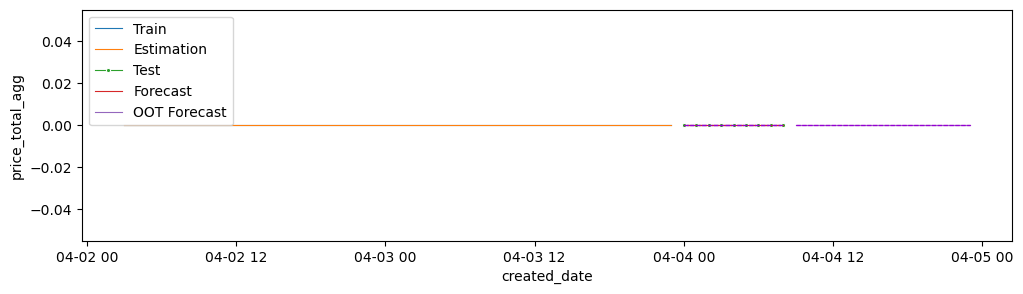

n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 0.000
train MAE:  0.000
test RMSE: 0.000
test MAE:  0.000


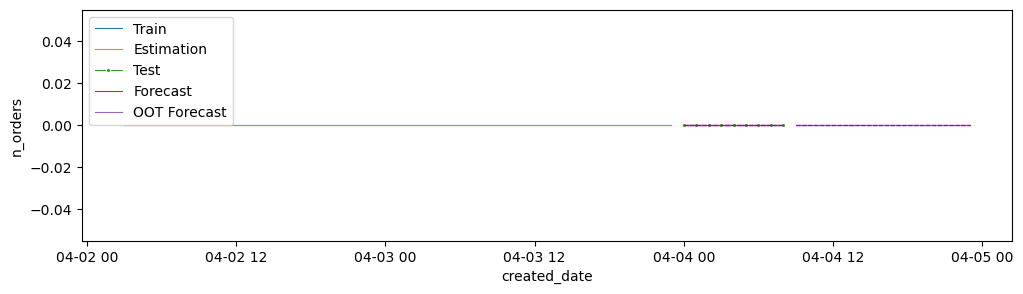

account_id: 9d39683a-47b3-4a18-942d-f1d741a47e8c
sales_channel_id: 1
price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 16403.150
train MAE:  11671.944
test RMSE: 10546.608
test MAE:  5562.715


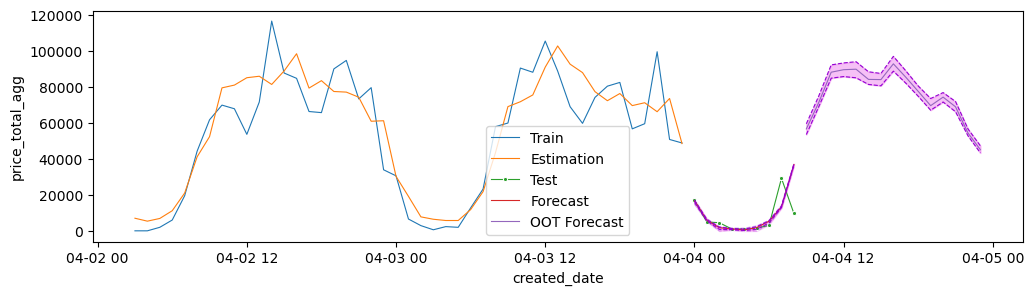

n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 9.469
train MAE:  7.141
test RMSE: 11.471
test MAE:  6.102


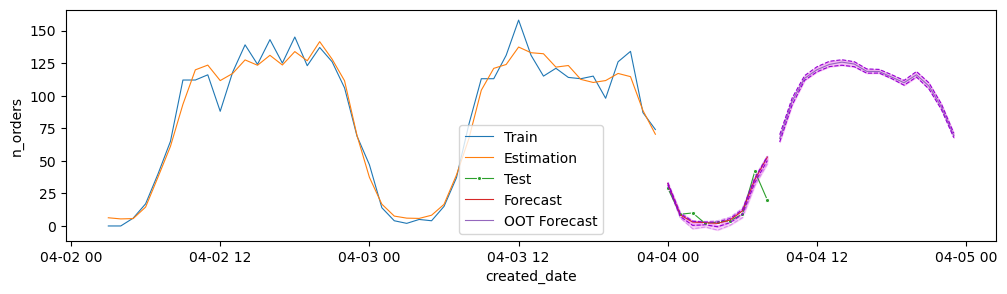

account_id: 05d9cc3a-decc-4fa2-b4e8-b44eef40e3b6
sales_channel_id: 3
price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 6873.123
train MAE:  4023.164
test RMSE: 2298.226
test MAE:  1489.039


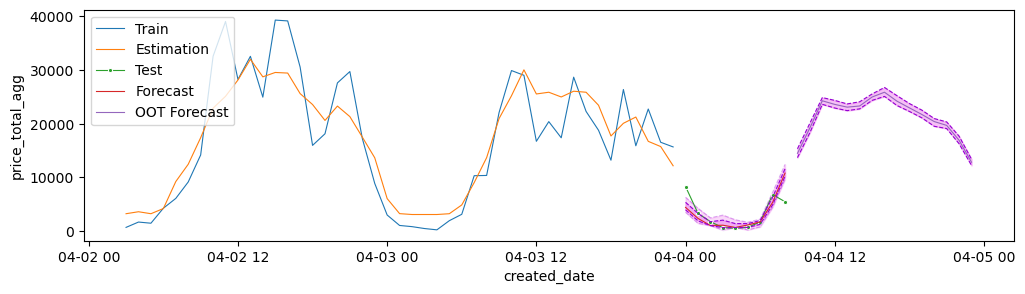

n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 9.283
train MAE:  6.920
test RMSE: 12.253
test MAE:  5.869


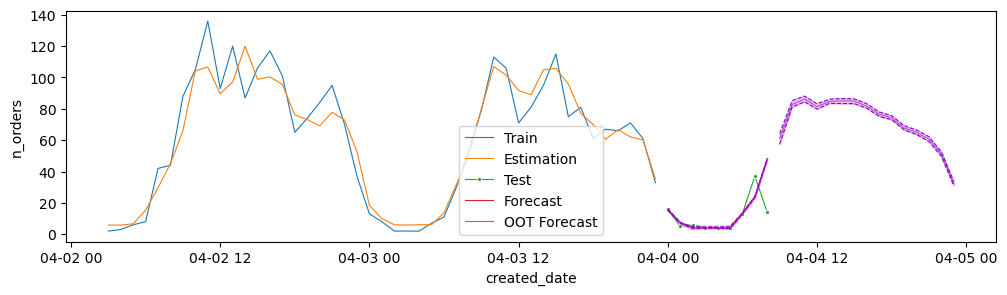

account_id: 5f5ed10c-7792-4080-970c-b11398e3f58f
sales_channel_id: 9
price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 0.000
train MAE:  0.000
test RMSE: 0.000
test MAE:  0.000


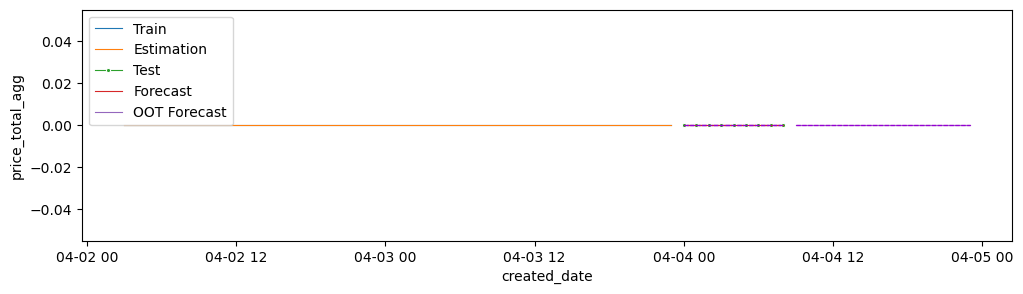

n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 0.000
train MAE:  0.000
test RMSE: 0.000
test MAE:  0.000


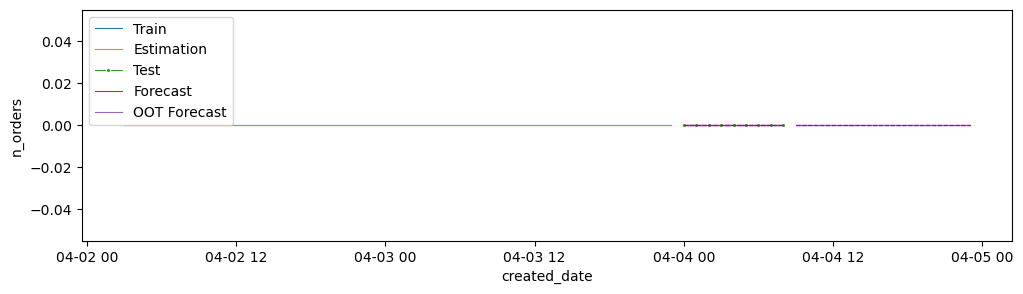

account_id: 74abffac-6542-4eff-8eae-cc85463a5d02
sales_channel_id: 1
price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 1022.578
train MAE:  786.981
test RMSE: 1274.852
test MAE:  996.950


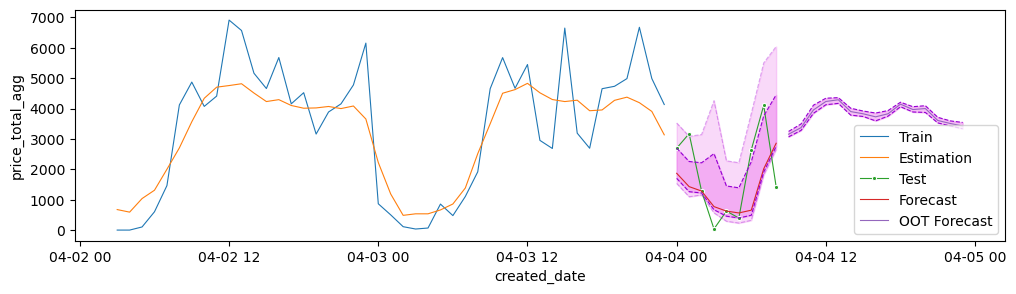

n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 4.858
train MAE:  3.724
test RMSE: 5.011
test MAE:  3.517


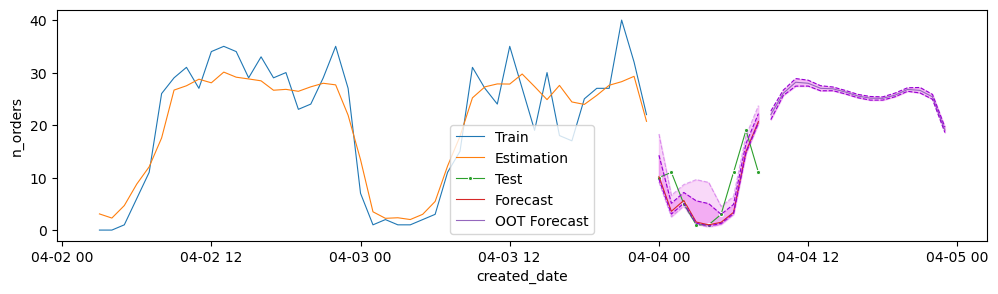

account_id: 05d9cc3a-decc-4fa2-b4e8-b44eef40e3b6
sales_channel_id: 6
price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 3668.094
train MAE:  2795.870
test RMSE: 2790.049
test MAE:  1723.807


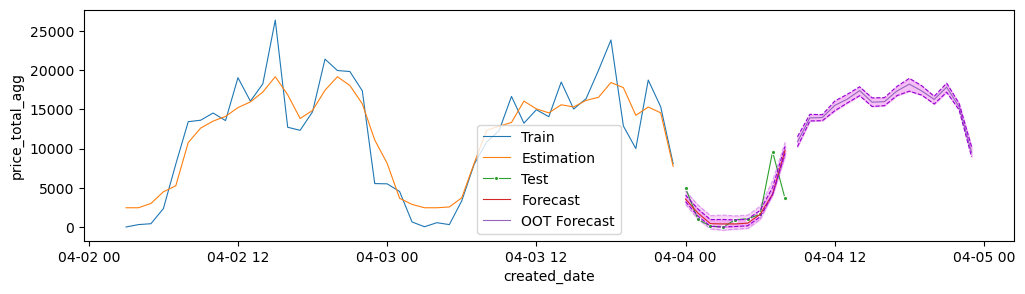

n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 2.661
train MAE:  1.815
test RMSE: 6.893
test MAE:  3.200


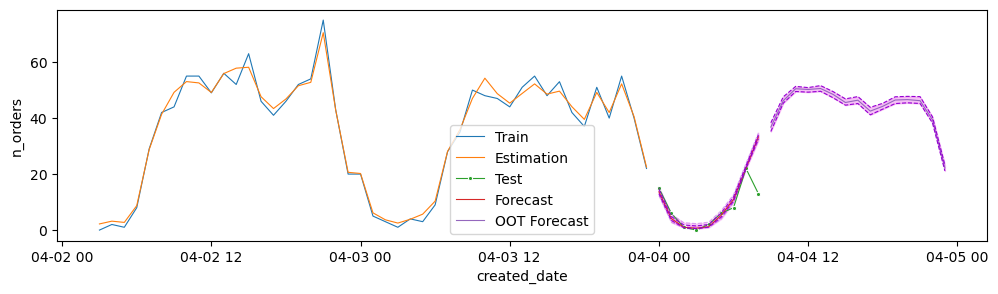

account_id: 5f5ed10c-7792-4080-970c-b11398e3f58f
sales_channel_id: 7
price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 0.000
train MAE:  0.000
test RMSE: 0.000
test MAE:  0.000


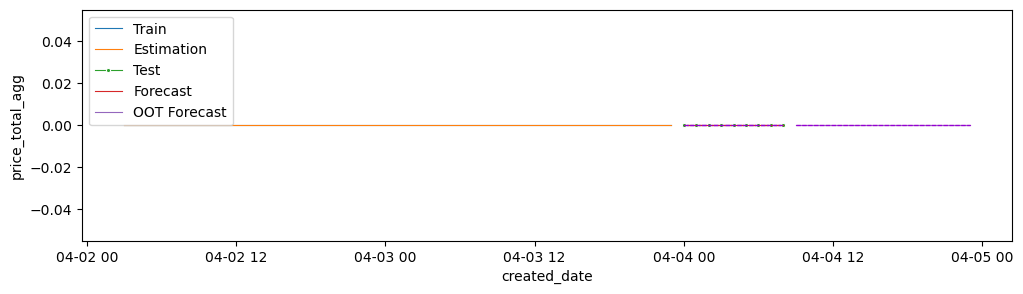

n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 0.000
train MAE:  0.000
test RMSE: 0.000
test MAE:  0.000


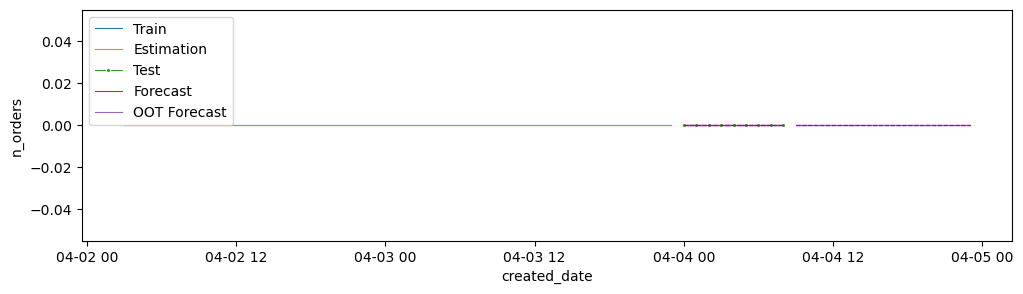

account_id: f9129295-bb08-4330-b60c-9f0beadda521
sales_channel_id: 1
price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 36551.552
train MAE:  26599.439
test RMSE: 26423.538
test MAE:  18181.066


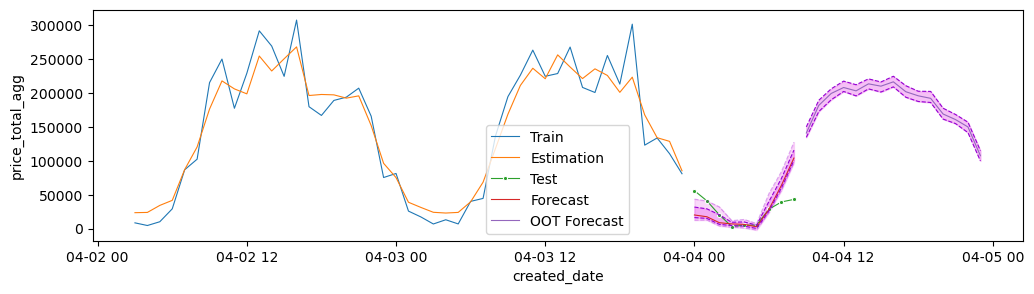

n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 5.615
train MAE:  3.573
test RMSE: 10.261
test MAE:  6.313


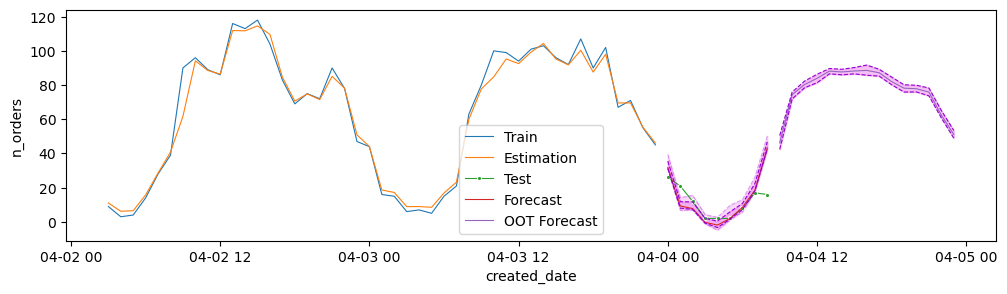

account_id: 60c8f748-e29d-4fce-9e66-584117ca2baf
sales_channel_id: 1
price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 3856.859
train MAE:  2693.247
test RMSE: 2890.376
test MAE:  2212.234


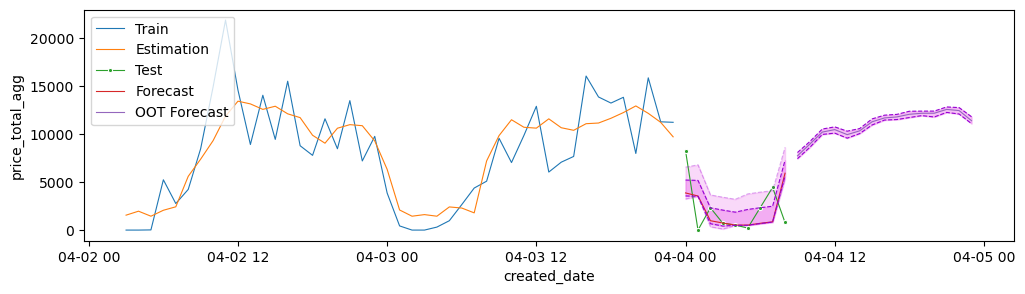

n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 5.068
train MAE:  3.668
test RMSE: 3.011
test MAE:  2.286


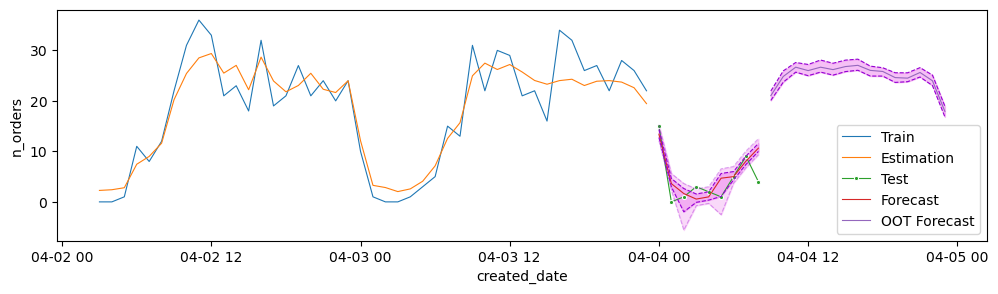

account_id: 40074fa8-e02b-4c91-a819-fe1e639b540d
sales_channel_id: 1
price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 2165.172
train MAE:  658.377
test RMSE: 3856.897
test MAE:  1915.135


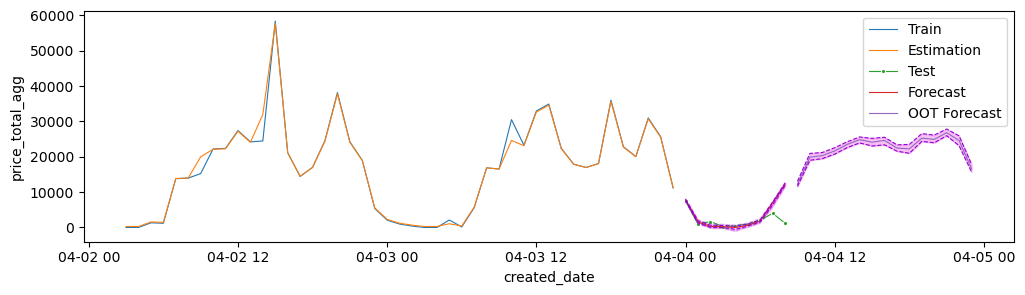

n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 8.989
train MAE:  6.552
test RMSE: 7.978
test MAE:  3.645


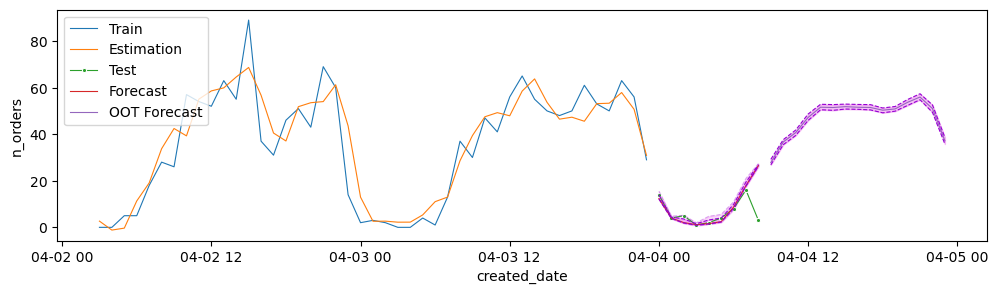

account_id: 5f5ed10c-7792-4080-970c-b11398e3f58f
sales_channel_id: 3
price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 0.000
train MAE:  0.000
test RMSE: 0.000
test MAE:  0.000


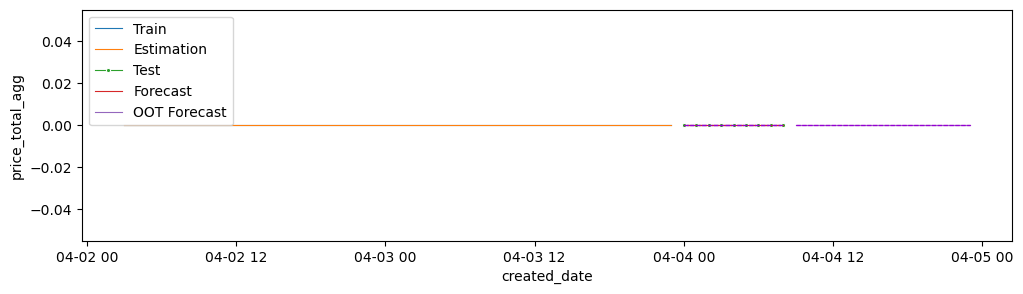

n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 0.000
train MAE:  0.000
test RMSE: 0.000
test MAE:  0.000


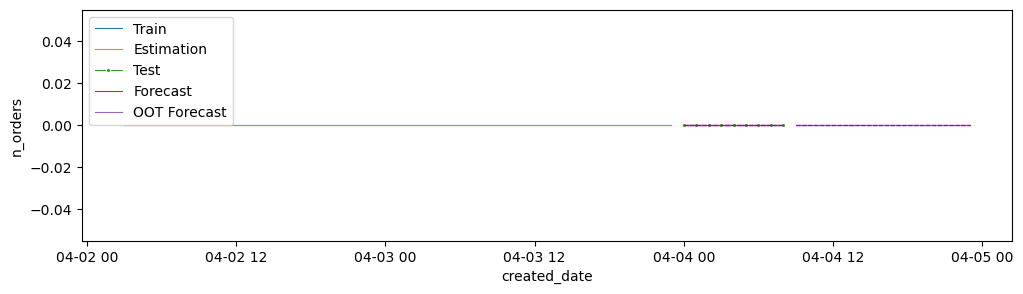

account_id: f9129295-bb08-4330-b60c-9f0beadda521
sales_channel_id: 2
price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 57336.020
train MAE:  33128.477
test RMSE: 4626.132
test MAE:  2717.405


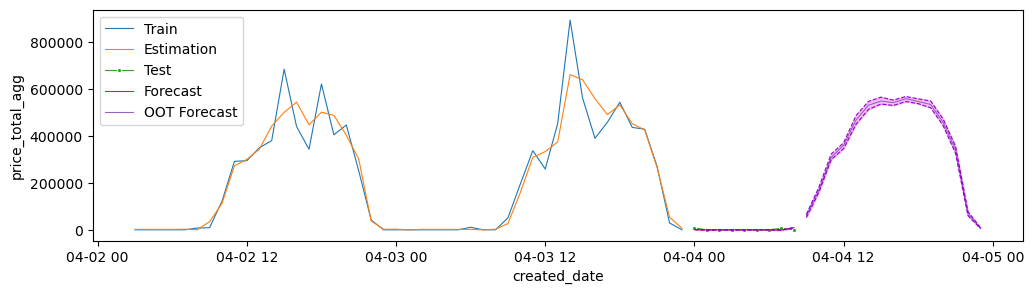

n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 10.149
train MAE:  3.561
test RMSE: 0.822
test MAE:  0.448


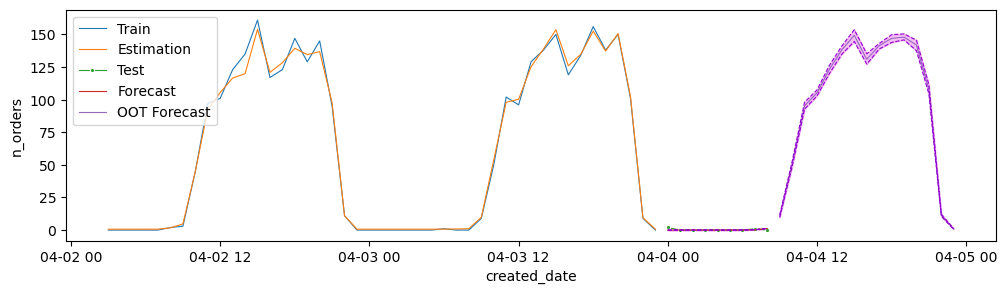

account_id: 173e2b27-8bc6-44d1-b581-a1913d6b1894
sales_channel_id: 1
price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 2780.553
train MAE:  2053.600
test RMSE: 1388.287
test MAE:  887.180


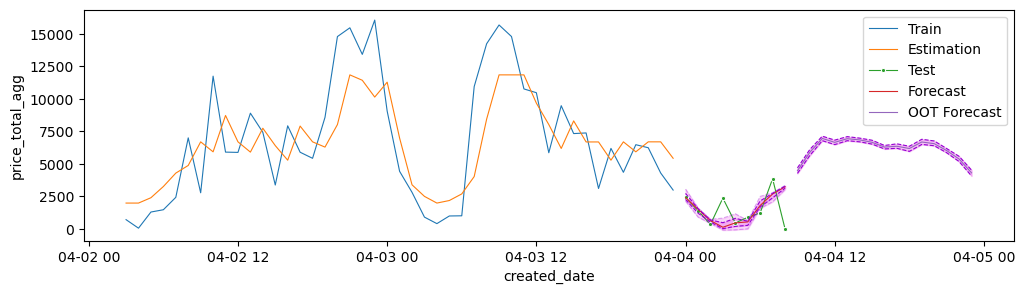

n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 5.381
train MAE:  3.957
test RMSE: 3.912
test MAE:  2.897


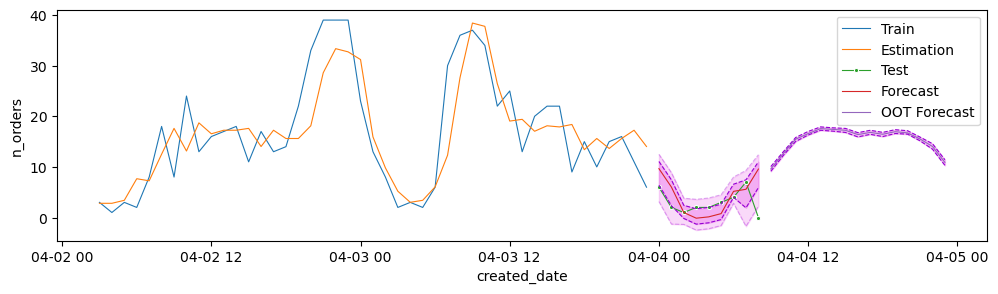

account_id: 5f5ed10c-7792-4080-970c-b11398e3f58f
sales_channel_id: 20
price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 0.000
train MAE:  0.000
test RMSE: 0.000
test MAE:  0.000


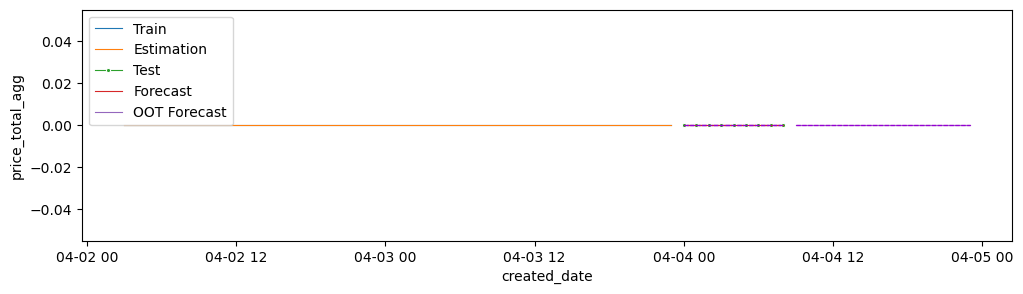

n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 0.000
train MAE:  0.000
test RMSE: 0.000
test MAE:  0.000


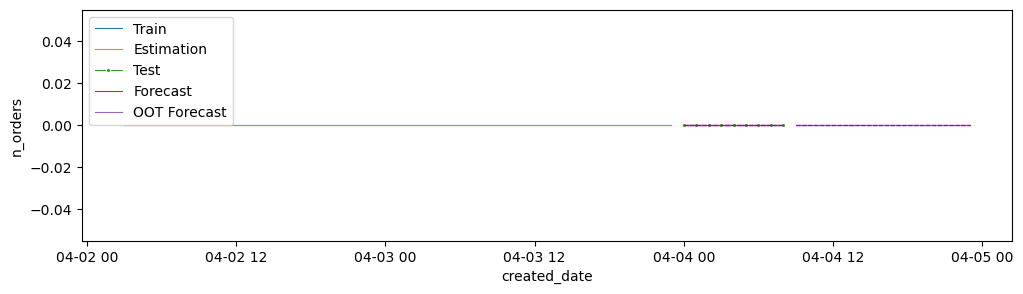

account_id: 5f5ed10c-7792-4080-970c-b11398e3f58f
sales_channel_id: 8
price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 0.000
train MAE:  0.000
test RMSE: 0.000
test MAE:  0.000


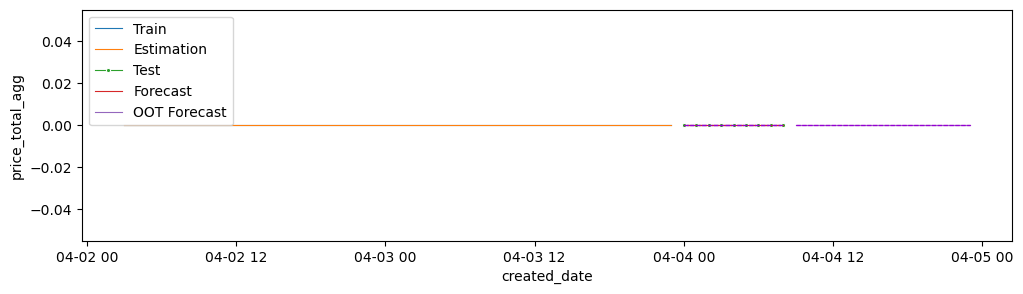

n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 0.000
train MAE:  0.000
test RMSE: 0.000
test MAE:  0.000


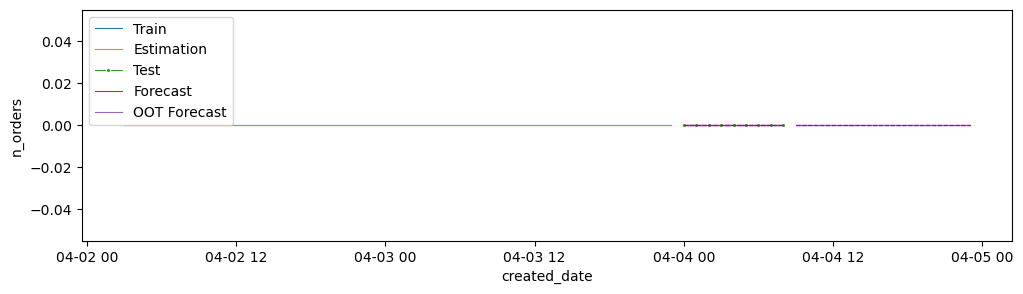

account_id: 05d9cc3a-decc-4fa2-b4e8-b44eef40e3b6
sales_channel_id: 5
price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 1109.902
train MAE:  709.108
test RMSE: 713.645
test MAE:  554.622


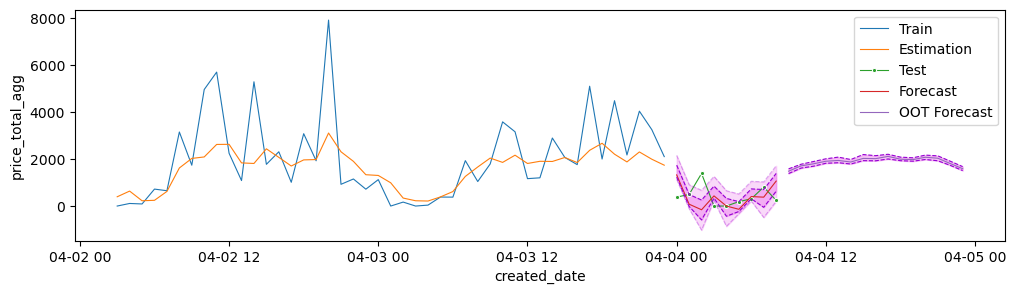

n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 4.565
train MAE:  2.230
test RMSE: 1.980
test MAE:  1.405


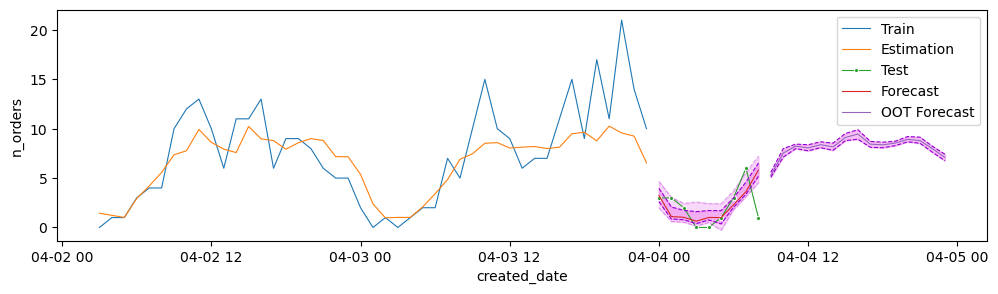

account_id: 5f5ed10c-7792-4080-970c-b11398e3f58f
sales_channel_id: 35
price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 0.000
train MAE:  0.000
test RMSE: 0.000
test MAE:  0.000


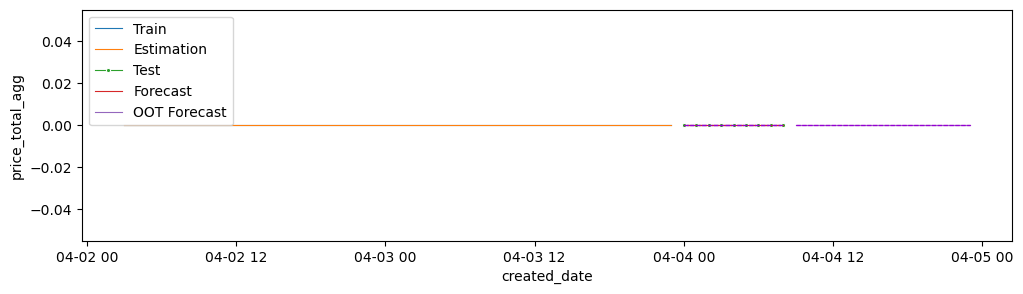

n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 0.000
train MAE:  0.000
test RMSE: 0.000
test MAE:  0.000


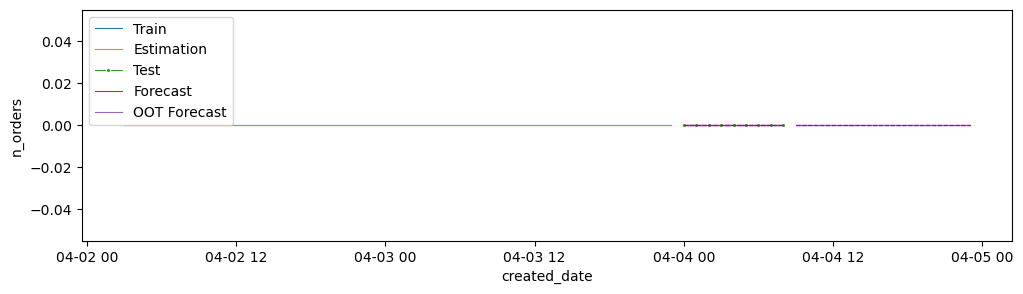

account_id: 478cd985-f4fc-45b4-ac71-bf78cf11e07b
sales_channel_id: 1
price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 446.109
train MAE:  291.293
test RMSE: 0.000
test MAE:  0.000


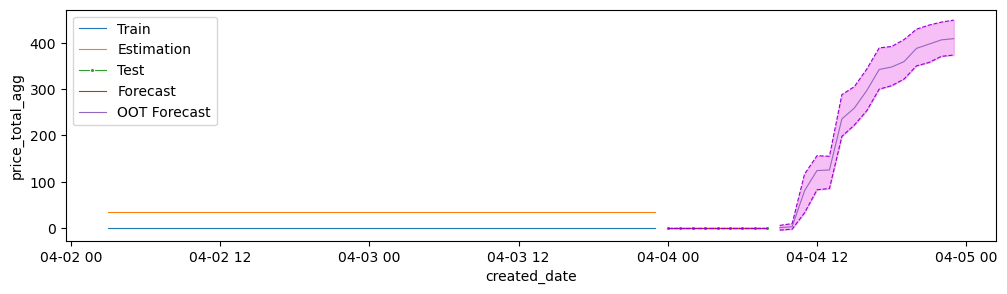

n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 1.812
train MAE:  1.155
test RMSE: 0.000
test MAE:  0.000


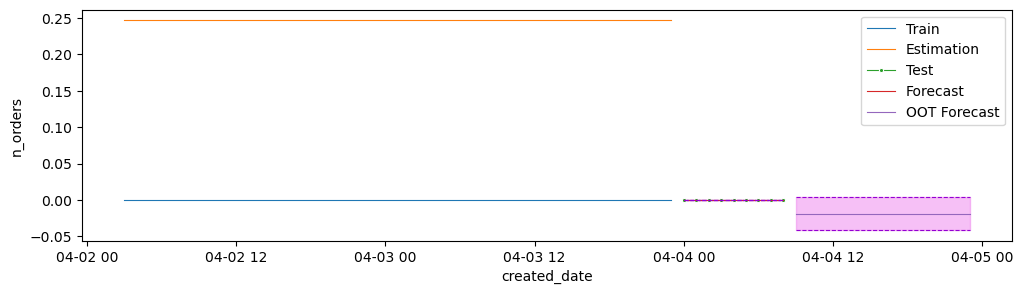

account_id: bfcbb283-4e53-41fd-9b31-aa818f7f23ce
sales_channel_id: 1
price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 1652.280
train MAE:  361.702
test RMSE: 52.559
test MAE:  32.947


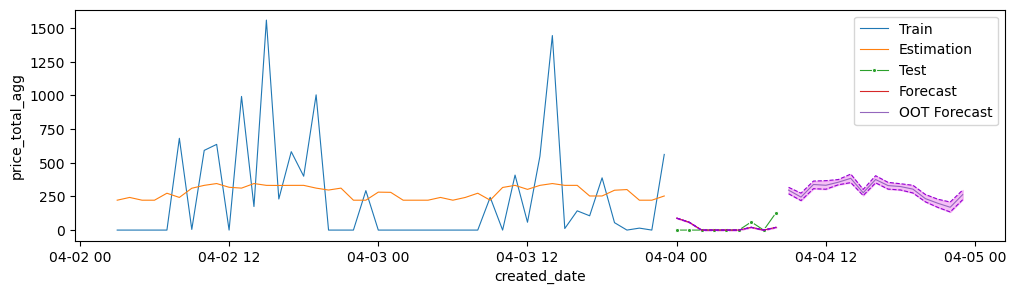

n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 1.368
train MAE:  0.884
test RMSE: 0.446
test MAE:  0.305


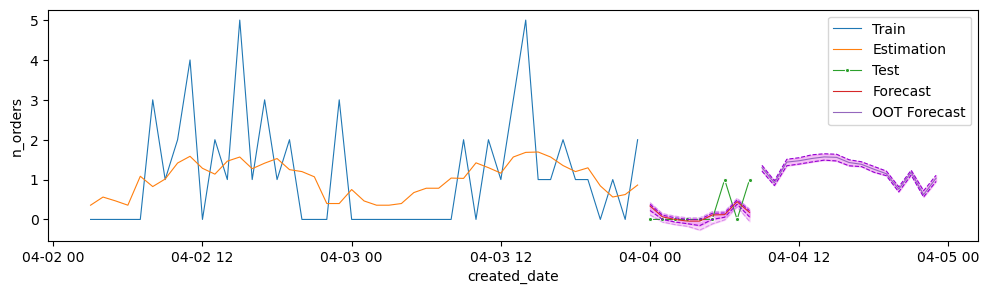

account_id: 60ca8452-5b14-481f-a637-8756f527aee8
sales_channel_id: 1
price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 0.000
train MAE:  0.000
test RMSE: 0.000
test MAE:  0.000


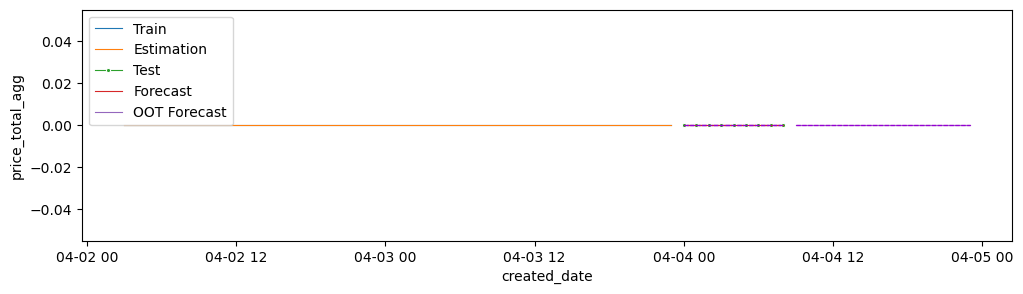

n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 0.000
train MAE:  0.000
test RMSE: 0.000
test MAE:  0.000


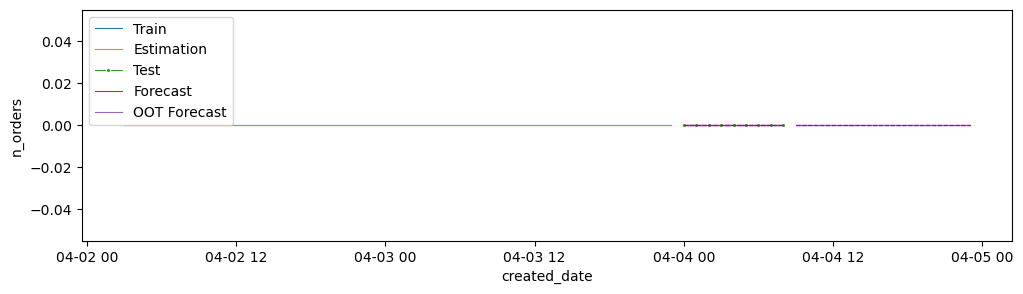

account_id: 50409b57-b000-43d5-9358-44c3081c4132
sales_channel_id: 1
price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 405.222
train MAE:  249.592
test RMSE: 35.610
test MAE:  29.351


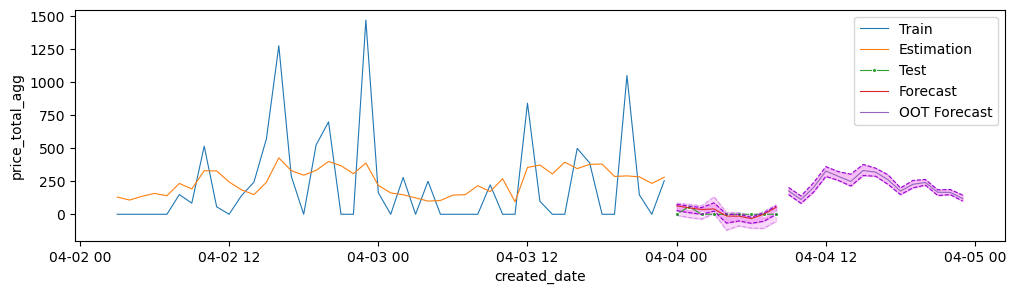

n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 1.045
train MAE:  0.729
test RMSE: 0.326
test MAE:  0.232


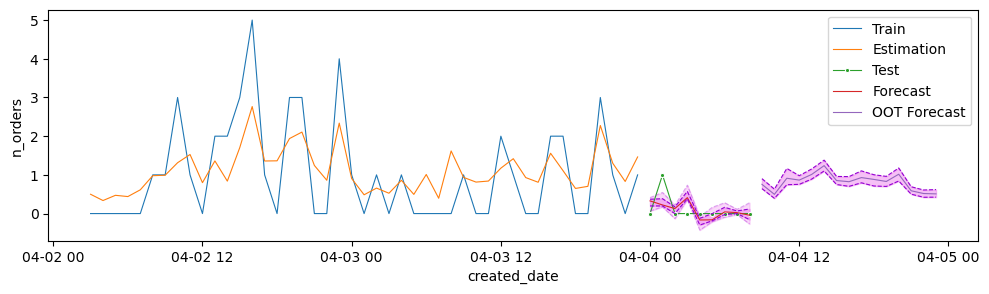

account_id: 74abffac-6542-4eff-8eae-cc85463a5d02
sales_channel_id: 2
price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 48.845
train MAE:  12.250
test RMSE: 3.823
test MAE:  1.363


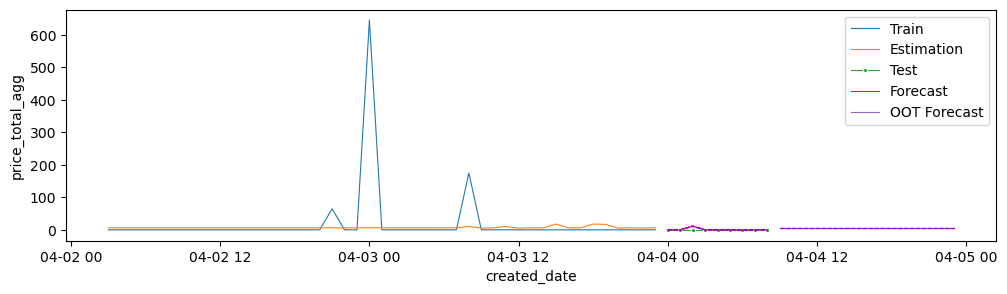

n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 0.194
train MAE:  0.058
test RMSE: 0.003
test MAE:  0.002


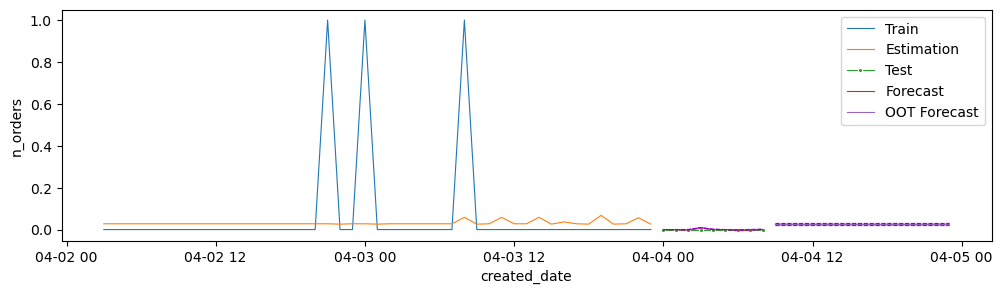

account_id: e2de40dd-743b-4105-9077-3f343fea980d
sales_channel_id: 1
price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 2404.983
train MAE:  1440.923
test RMSE: 1000.758
test MAE:  849.335


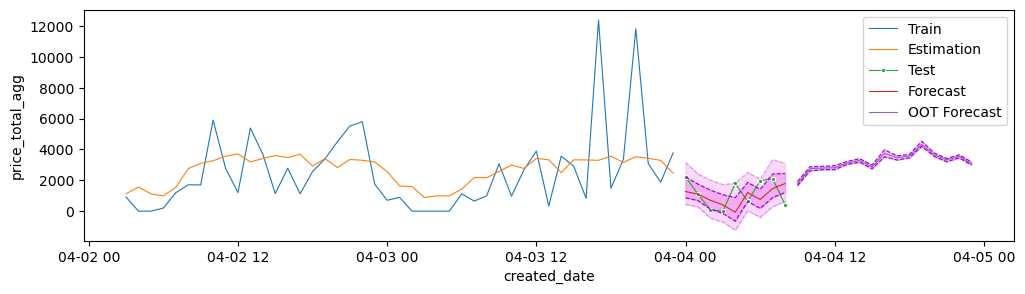

n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 3.567
train MAE:  2.696
test RMSE: 2.472
test MAE:  1.607


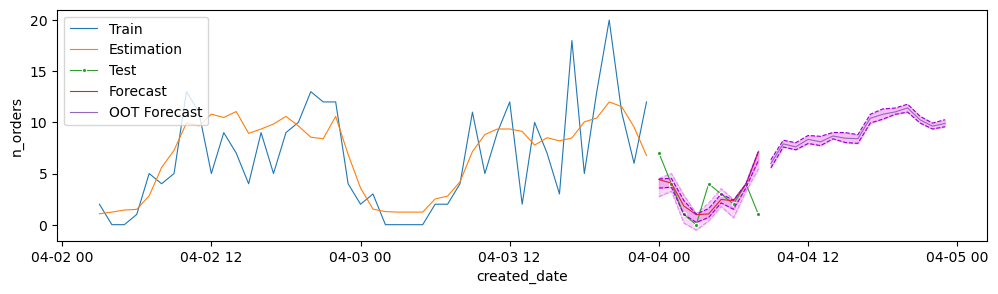

account_id: 5f5ed10c-7792-4080-970c-b11398e3f58f
sales_channel_id: 6
price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 0.000
train MAE:  0.000
test RMSE: 0.000
test MAE:  0.000


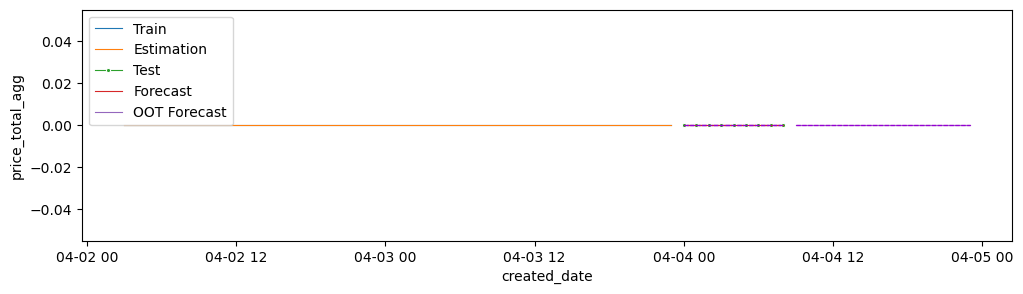

n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 0.000
train MAE:  0.000
test RMSE: 0.000
test MAE:  0.000


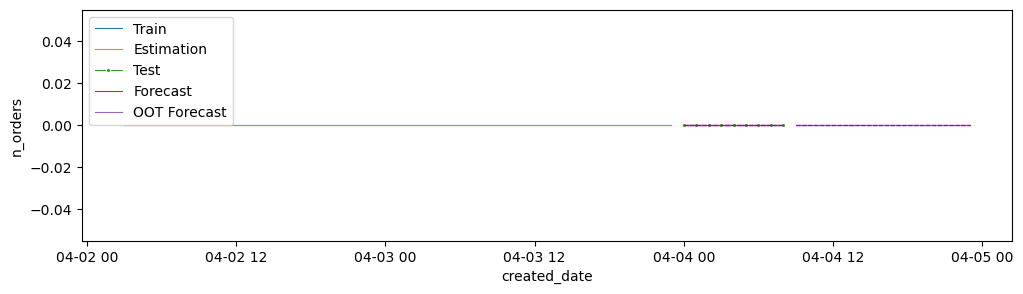

account_id: 6276b87c-ebb2-11ed-a05b-0242ac120003
sales_channel_id: 1
price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 28.124
train MAE:  8.998
test RMSE: 6.574
test MAE:  2.289


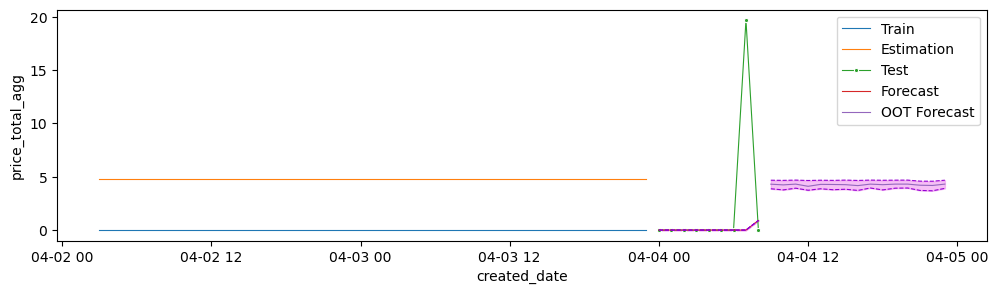

n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 0.187
train MAE:  0.073
test RMSE: 0.333
test MAE:  0.111


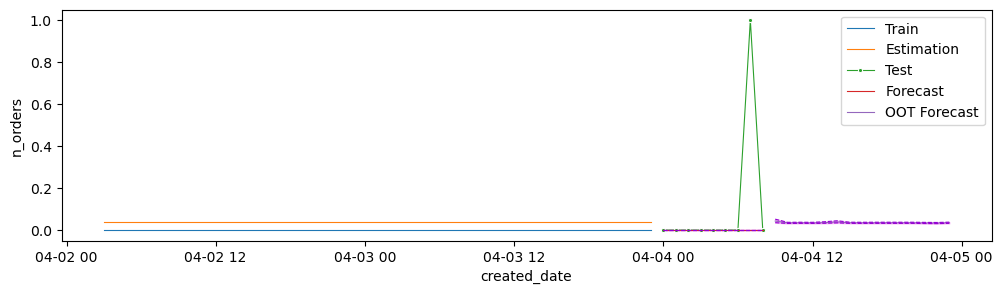

account_id: 5f5ed10c-7792-4080-970c-b11398e3f58f
sales_channel_id: 5
price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 0.000
train MAE:  0.000
test RMSE: 0.000
test MAE:  0.000


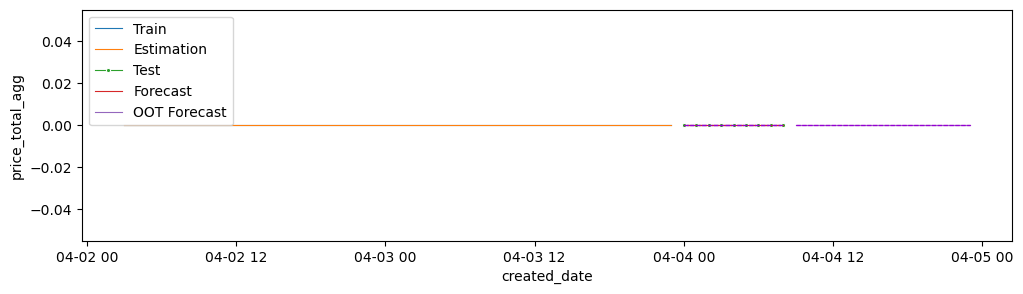

n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 0.000
train MAE:  0.000
test RMSE: 0.000
test MAE:  0.000


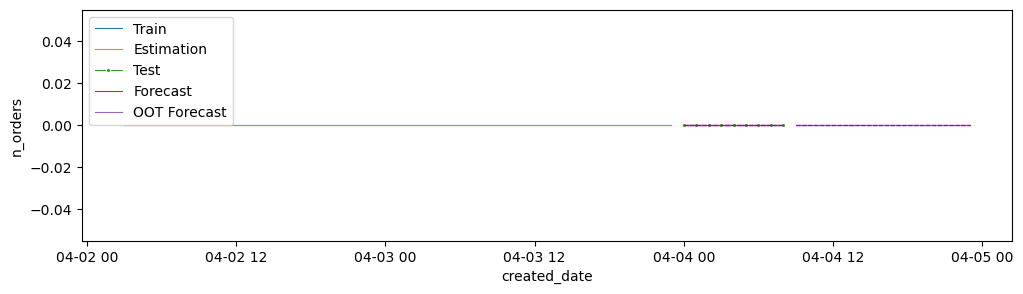

account_id: 5f5ed10c-7792-4080-970c-b11398e3f58f
sales_channel_id: 4
price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 0.000
train MAE:  0.000
test RMSE: 0.000
test MAE:  0.000


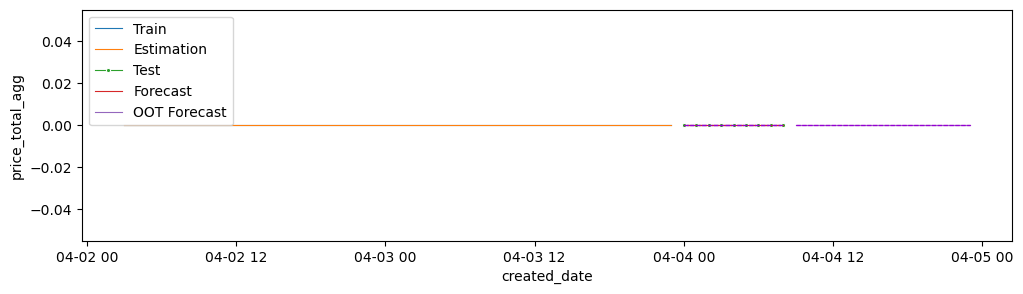

n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 0.000
train MAE:  0.000
test RMSE: 0.000
test MAE:  0.000


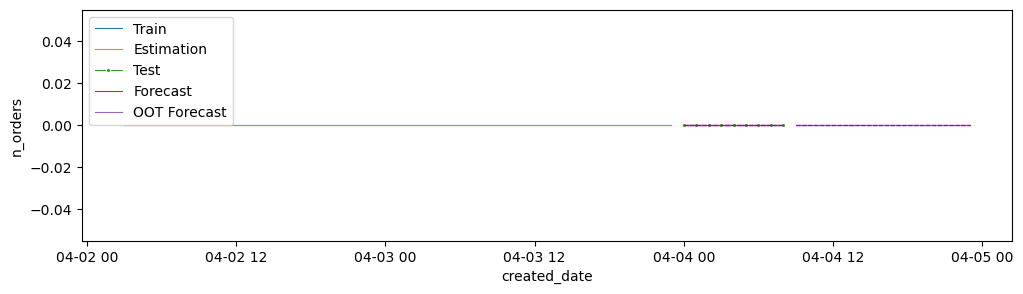

account_id: ca35e88d-d191-4722-b90c-92f4a249869b
sales_channel_id: 1
price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 473.747
train MAE:  360.398
test RMSE: 199.539
test MAE:  169.365


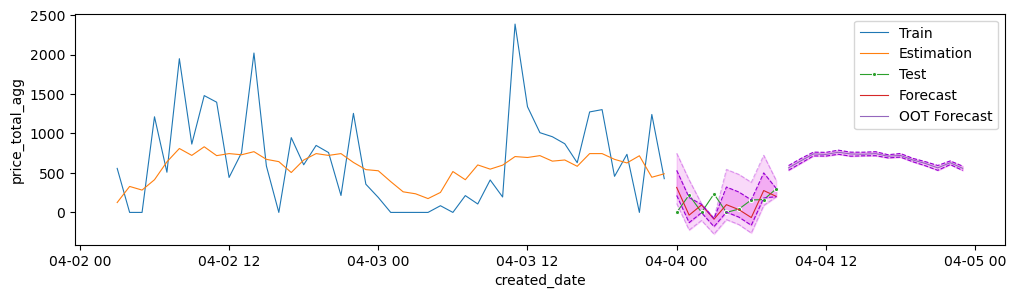

n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 1.625
train MAE:  1.242
test RMSE: 0.781
test MAE:  0.594


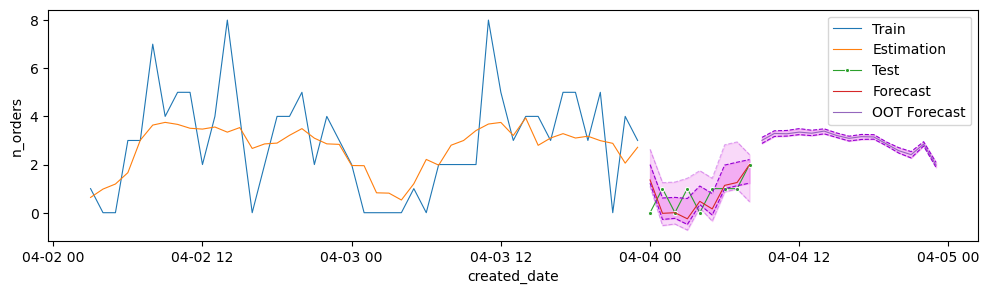

account_id: 775dcad4-0733-4c22-8dbd-cd3ce344e891
sales_channel_id: 2
price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 761.436
train MAE:  552.421
test RMSE: 45.238
test MAE:  18.613


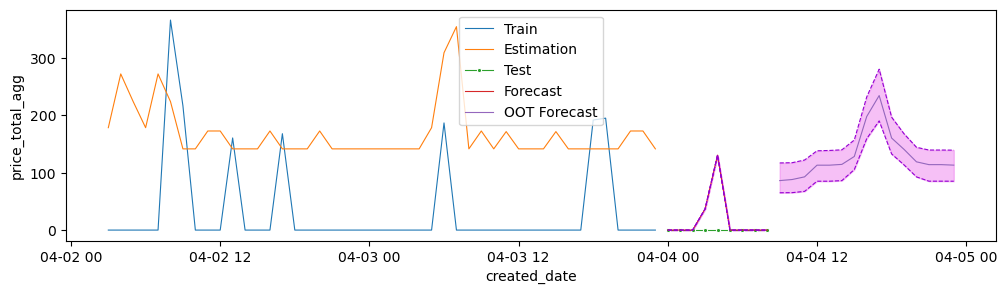

n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 2.118
train MAE:  1.609
test RMSE: 0.000
test MAE:  0.000


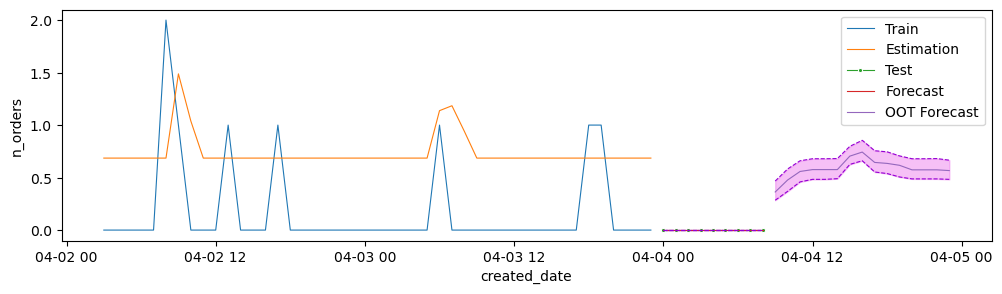

account_id: f9129295-bb08-4330-b60c-9f0beadda521
sales_channel_id: 10
price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 15218.648
train MAE:  11378.321
test RMSE: 10275.889
test MAE:  7143.783


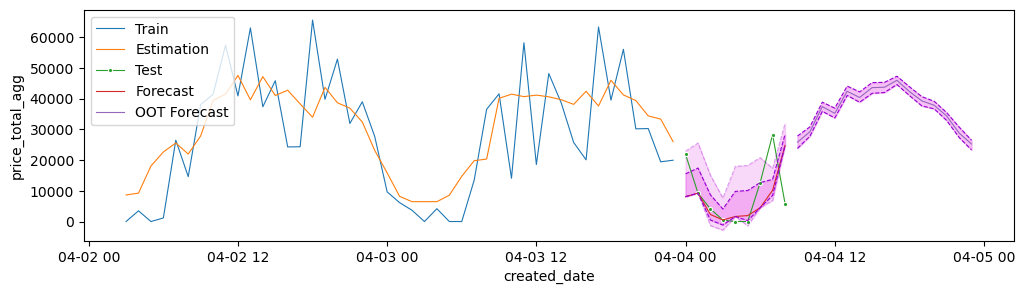

n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 4.361
train MAE:  3.362
test RMSE: 4.380
test MAE:  3.299


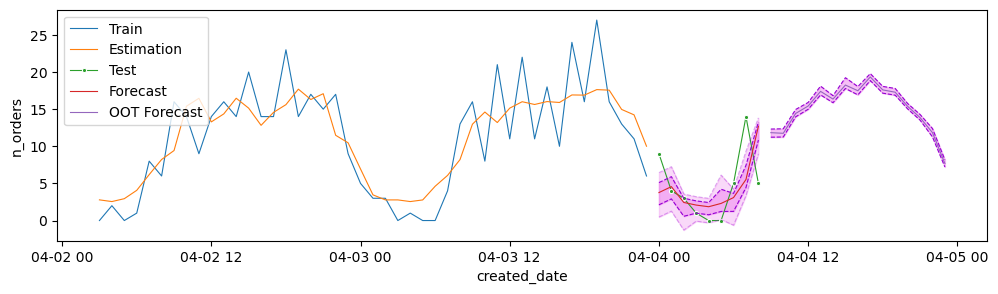

account_id: 5f5ed10c-7792-4080-970c-b11398e3f58f
sales_channel_id: 13
price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 0.000
train MAE:  0.000
test RMSE: 0.000
test MAE:  0.000


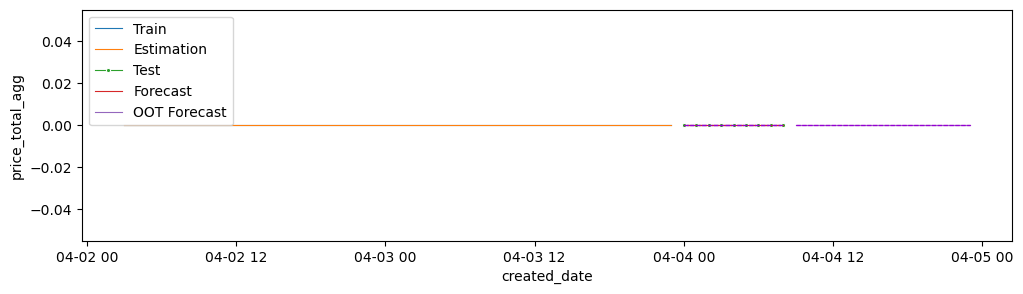

n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 0.000
train MAE:  0.000
test RMSE: 0.000
test MAE:  0.000


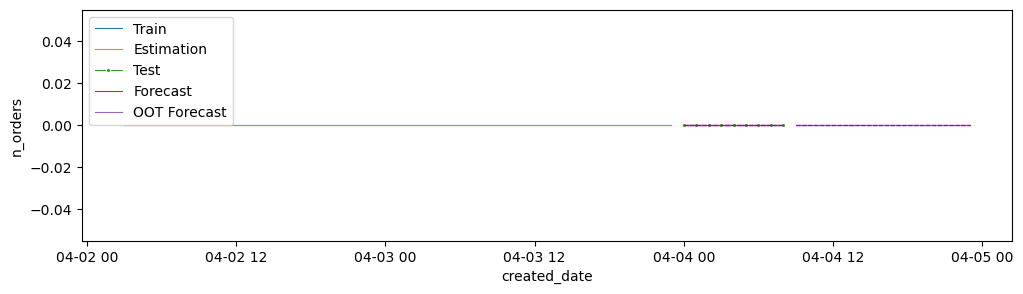

account_id: 7db6eaca-fe22-41d7-bfb8-1fdde880feb8
sales_channel_id: 1
price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 146.263
train MAE:  97.400
test RMSE: 253.403
test MAE:  157.849


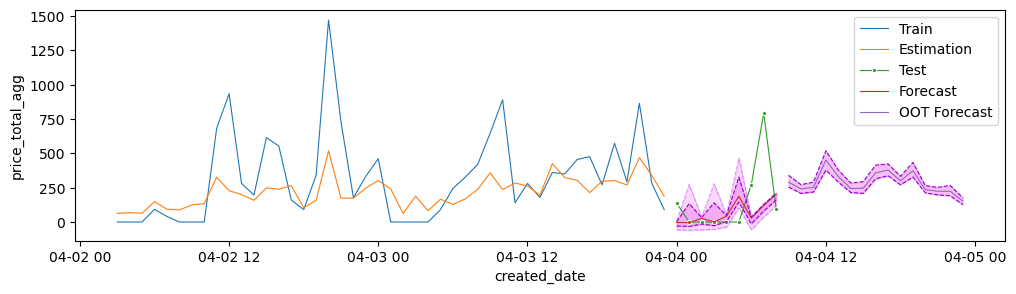

n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 0.759
train MAE:  0.498
test RMSE: 2.166
test MAE:  1.464


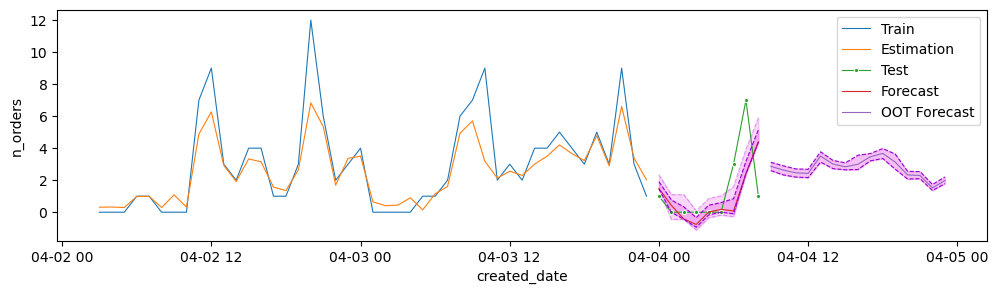

account_id: 6276b87c-ebb2-11ed-a05b-0242ac120003
sales_channel_id: 6
price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 0.000
train MAE:  0.000
test RMSE: 0.000
test MAE:  0.000


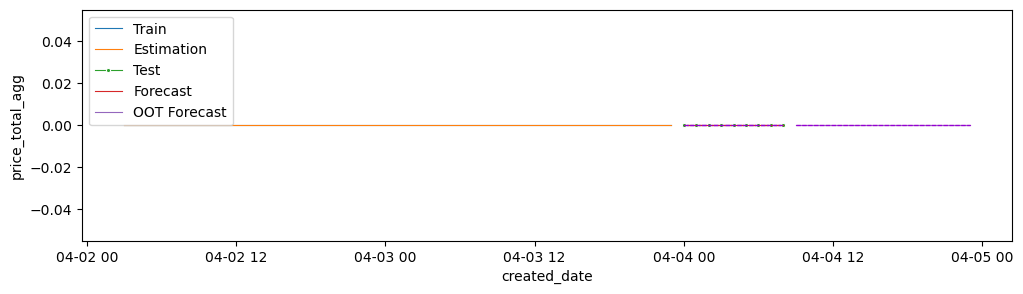

n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 0.000
train MAE:  0.000
test RMSE: 0.000
test MAE:  0.000


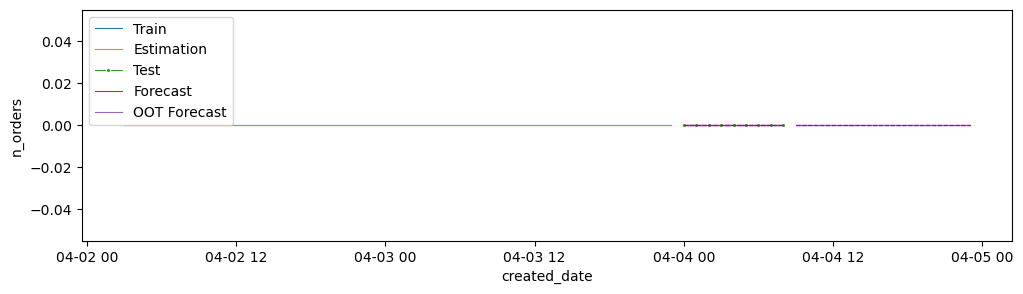

account_id: 5f5ed10c-7792-4080-970c-b11398e3f58f
sales_channel_id: 24
price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 0.000
train MAE:  0.000
test RMSE: 0.000
test MAE:  0.000


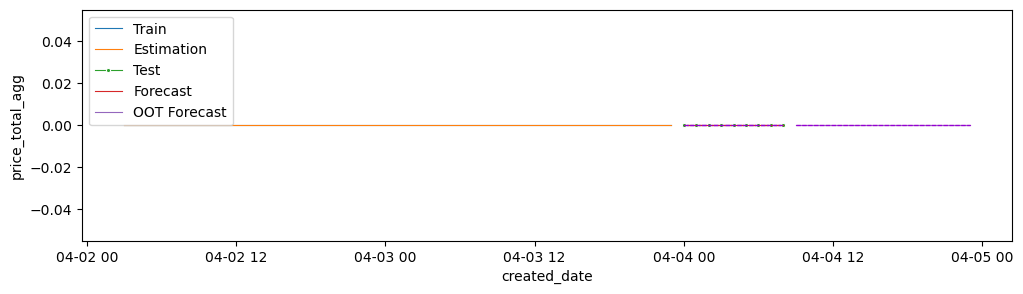

n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 0.000
train MAE:  0.000
test RMSE: 0.000
test MAE:  0.000


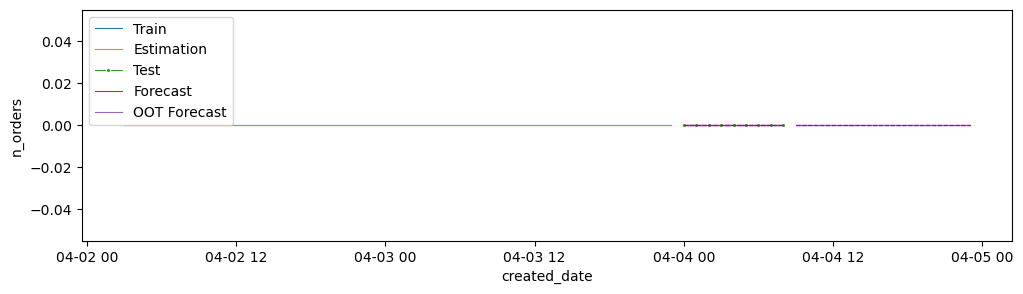

account_id: 0661e926-f219-456e-bde5-612fee6f891c
sales_channel_id: 1
price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 1327.128
train MAE:  602.659
test RMSE: 188.042
test MAE:  99.242


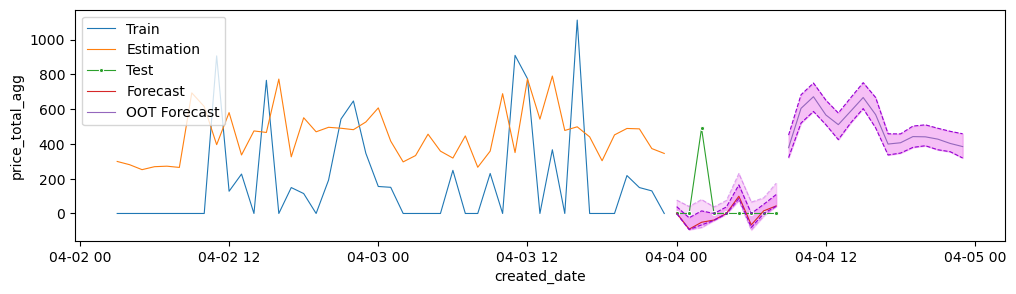

n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 7.239
train MAE:  3.011
test RMSE: 0.347
test MAE:  0.143


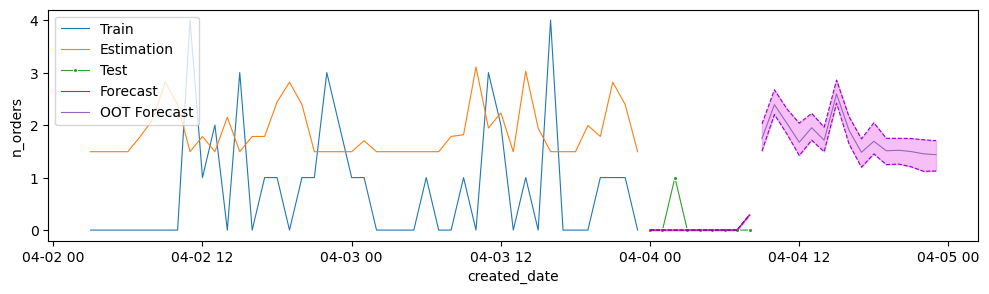

account_id: 92f116fe-5818-41db-9eb5-87445ad3818e
sales_channel_id: 5
price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 546.207
train MAE:  408.569
test RMSE: 315.755
test MAE:  244.143


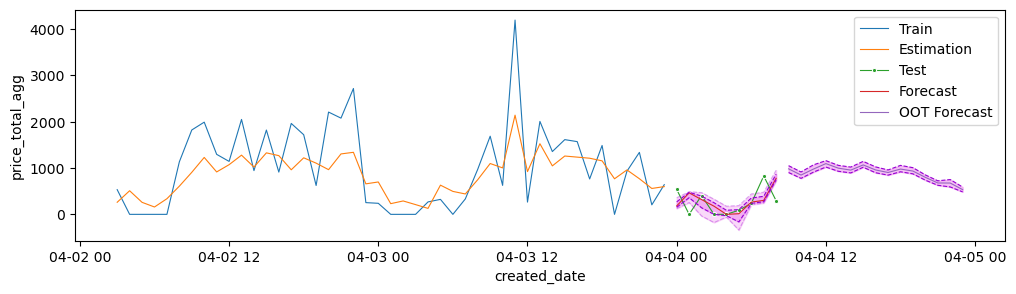

n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 1.561
train MAE:  1.195
test RMSE: 0.675
test MAE:  0.539


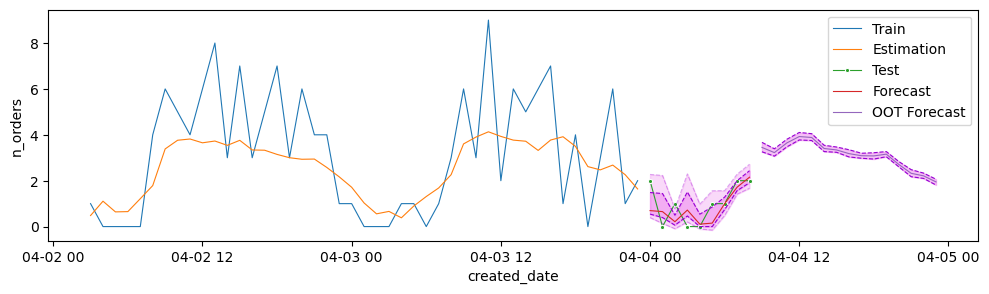

account_id: 5dd8b3ee-6f1c-4ac9-bbc5-91829dde38eb
sales_channel_id: 1
price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 2062.993
train MAE:  1556.446
test RMSE: 1682.754
test MAE:  1319.526


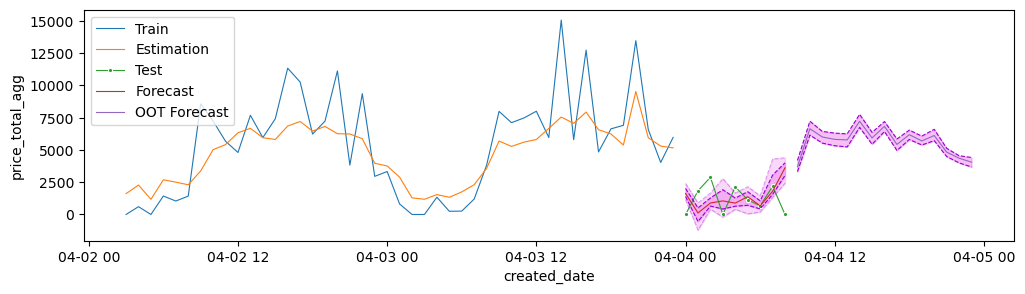

n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 4.274
train MAE:  3.045
test RMSE: 4.628
test MAE:  3.372


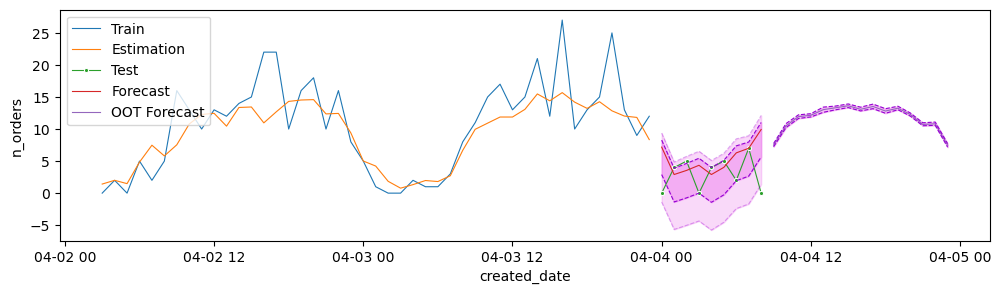

account_id: b8c6ac4b-2999-40f4-ad33-17649fb2f0aa
sales_channel_id: 1
price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 2299.731
train MAE:  1596.963
test RMSE: 475.329
test MAE:  334.540


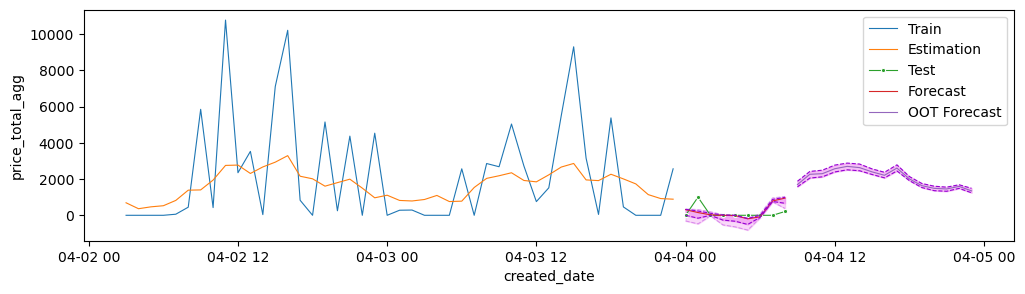

n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 1.054
train MAE:  0.805
test RMSE: 0.390
test MAE:  0.262


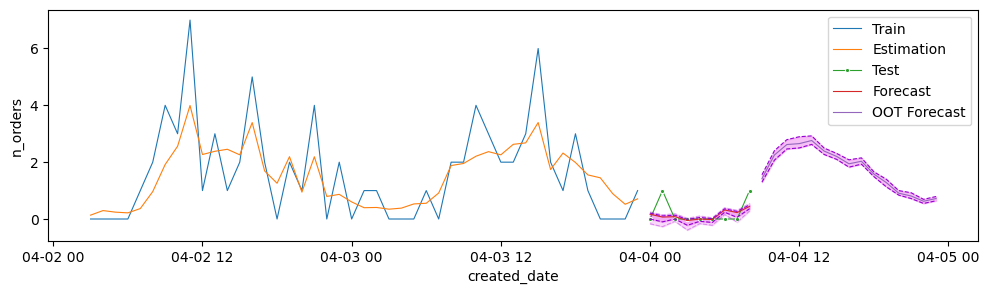

account_id: f4471620-212b-4991-98d3-b498835d0c29
sales_channel_id: 1
price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 0.000
train MAE:  0.000
test RMSE: 0.000
test MAE:  0.000


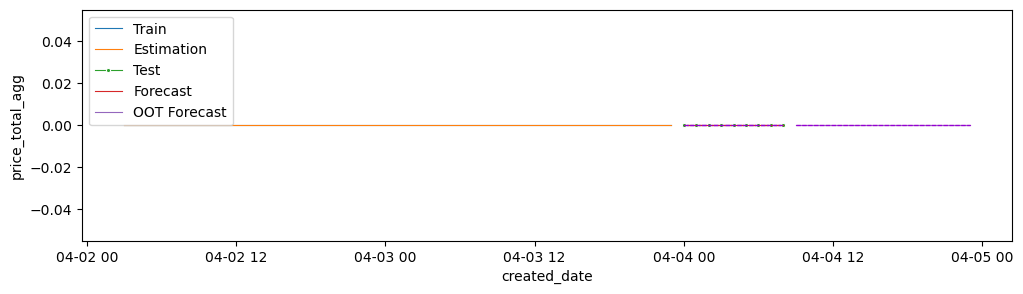

n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 0.000
train MAE:  0.000
test RMSE: 0.000
test MAE:  0.000


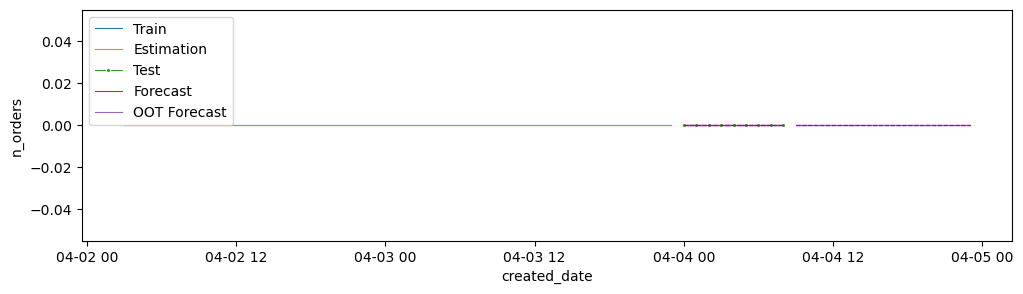

account_id: 5f5ed10c-7792-4080-970c-b11398e3f58f
sales_channel_id: 16
price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 0.000
train MAE:  0.000
test RMSE: 0.000
test MAE:  0.000


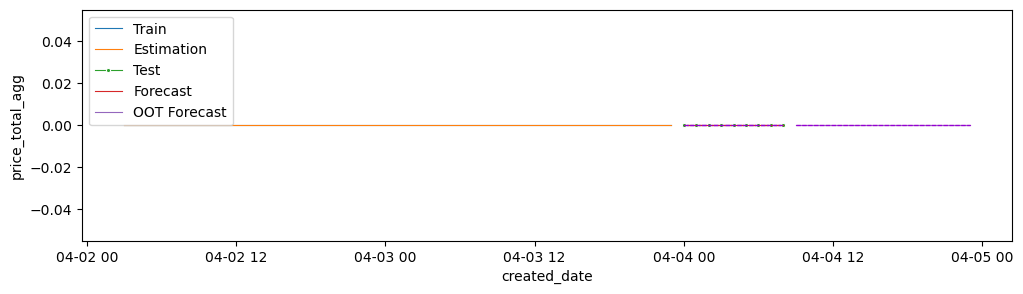

n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 0.000
train MAE:  0.000
test RMSE: 0.000
test MAE:  0.000


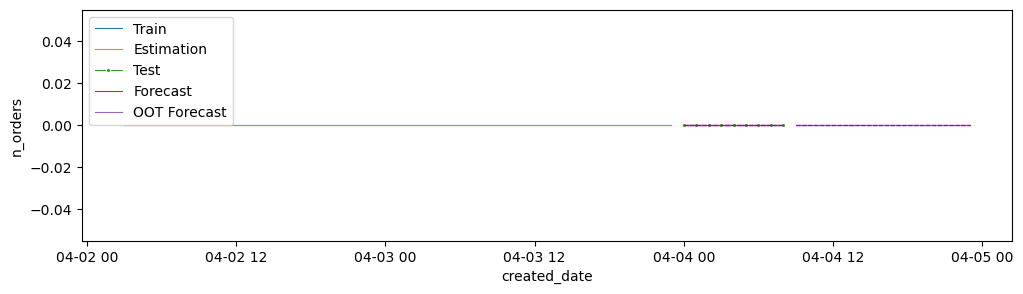

account_id: 789ff5c4-21d8-4ed3-ab64-8b46cf2eba9b
sales_channel_id: 1
price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 332.914
train MAE:  212.962
test RMSE: 394.103
test MAE:  222.613


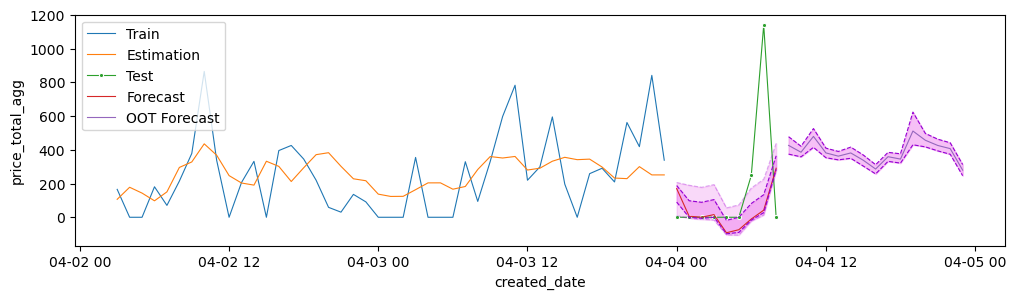

n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 4.645
train MAE:  1.874
test RMSE: 0.693
test MAE:  0.385


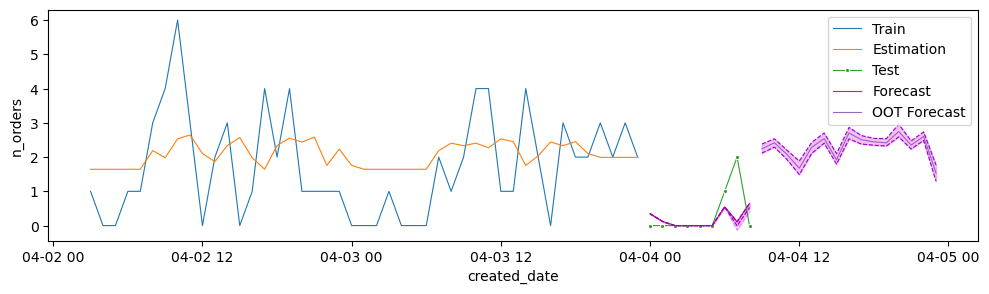

account_id: ad942d1a-15ab-4a0d-83a8-ae82183ece53
sales_channel_id: 1
price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 378.695
train MAE:  264.618
test RMSE: 151.295
test MAE:  108.332


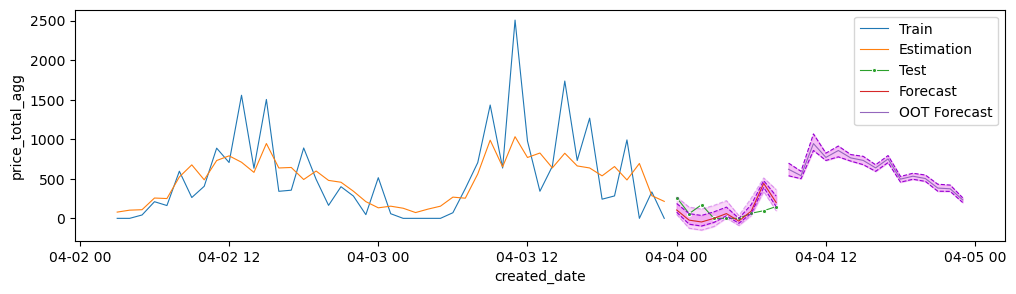

n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 2.052
train MAE:  1.562
test RMSE: 1.002
test MAE:  0.574


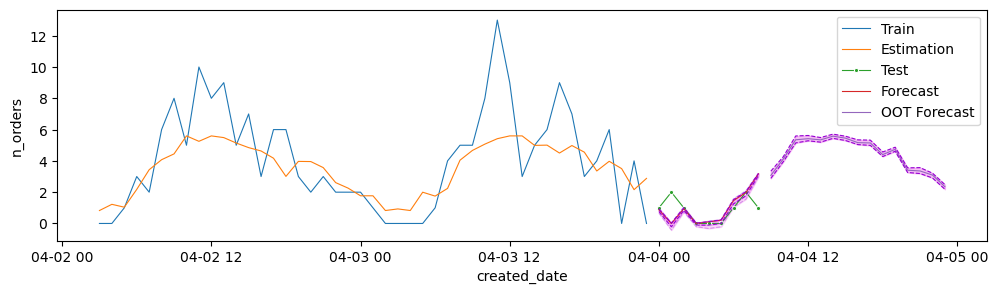

account_id: c0cc925b-66c1-4b1c-b609-1bddc82ef4a4
sales_channel_id: 1
price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 23.321
train MAE:  5.576
test RMSE: 0.000
test MAE:  0.000


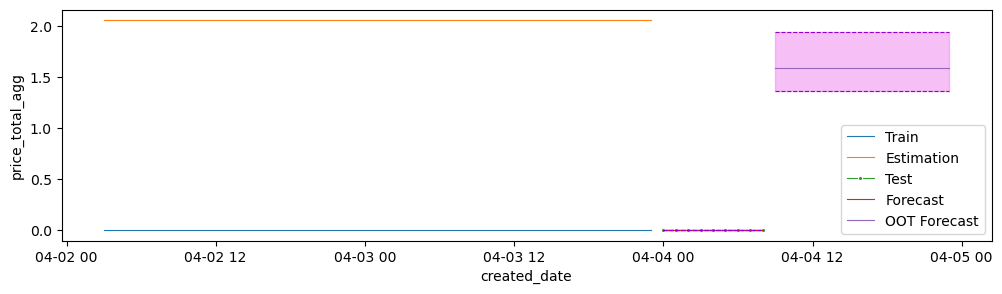

n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 0.144
train MAE:  0.036
test RMSE: 0.000
test MAE:  0.000


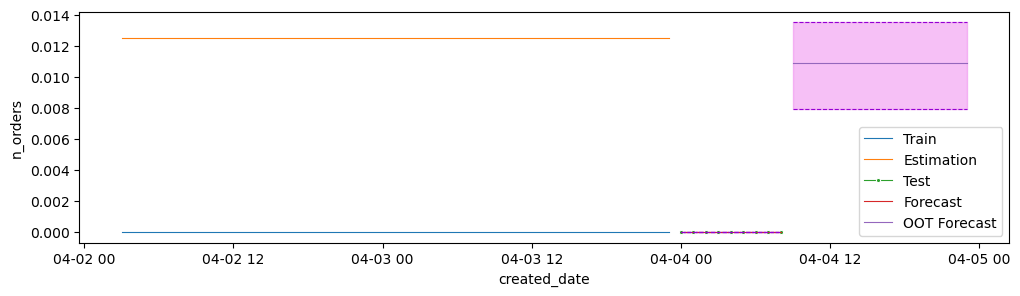

account_id: d639773a-df2c-421e-ac87-6918a754572f
sales_channel_id: 1
price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 714.947
train MAE:  421.996
test RMSE: 605.416
test MAE:  309.320


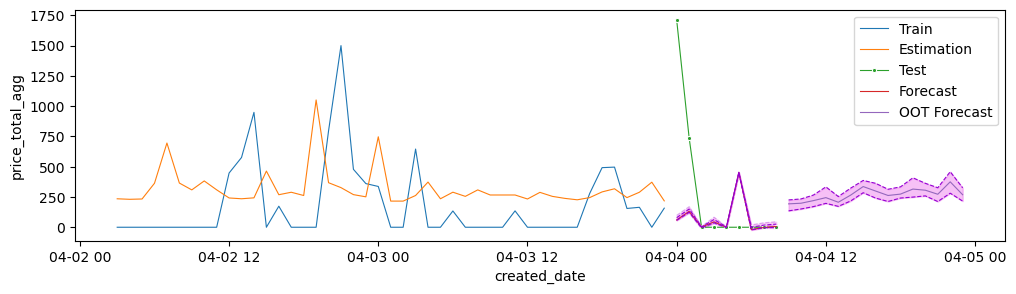

n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 0.547
train MAE:  0.395
test RMSE: 0.655
test MAE:  0.343


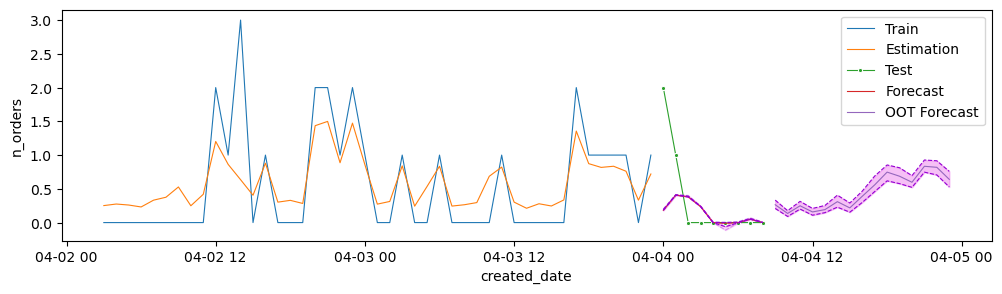

account_id: 5f5ed10c-7792-4080-970c-b11398e3f58f
sales_channel_id: 14
price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 0.000
train MAE:  0.000
test RMSE: 0.000
test MAE:  0.000


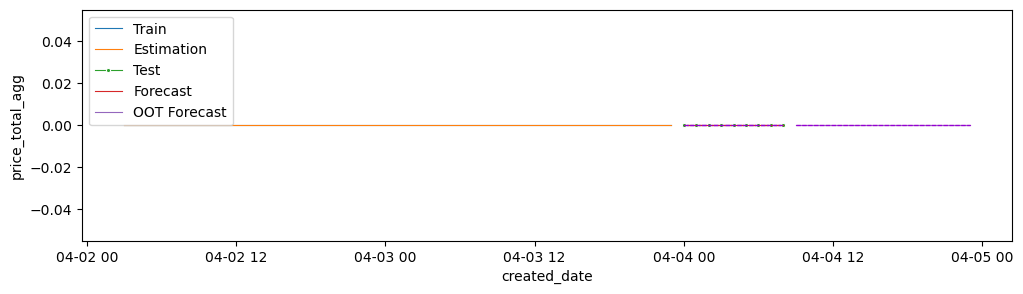

n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 0.000
train MAE:  0.000
test RMSE: 0.000
test MAE:  0.000


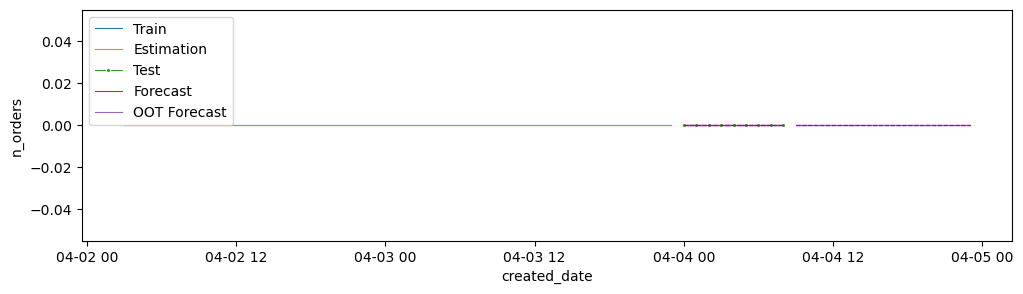

account_id: 7412074f-0f3a-4724-b035-7fb4db3174c8
sales_channel_id: 1
price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 688.730
train MAE:  433.786
test RMSE: 0.000
test MAE:  0.000


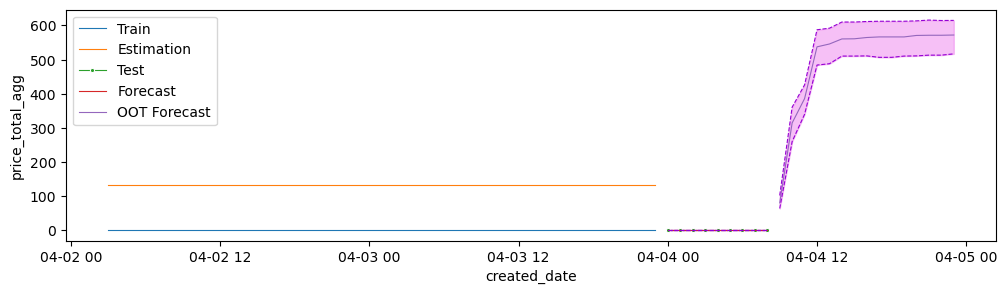

n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 1.023
train MAE:  0.661
test RMSE: 0.000
test MAE:  0.000


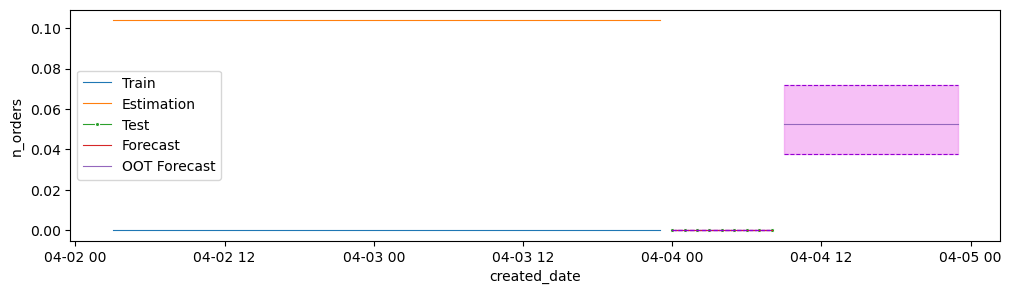

account_id: ad942d1a-15ab-4a0d-83a8-ae82183ece53
sales_channel_id: 2
price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 296.452
train MAE:  199.510
test RMSE: 204.263
test MAE:  142.479


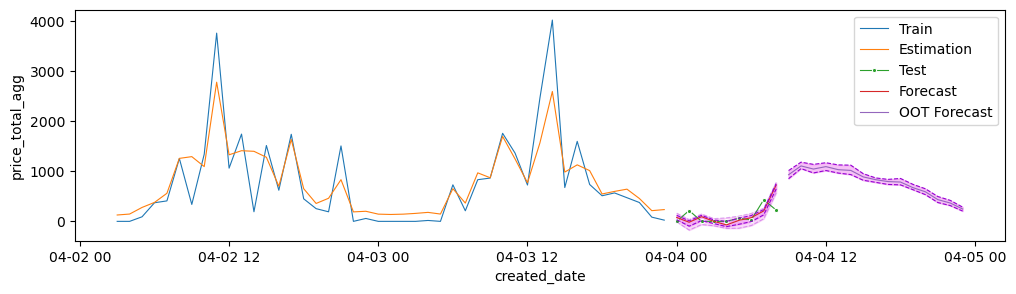

n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 2.600
train MAE:  1.968
test RMSE: 1.157
test MAE:  0.808


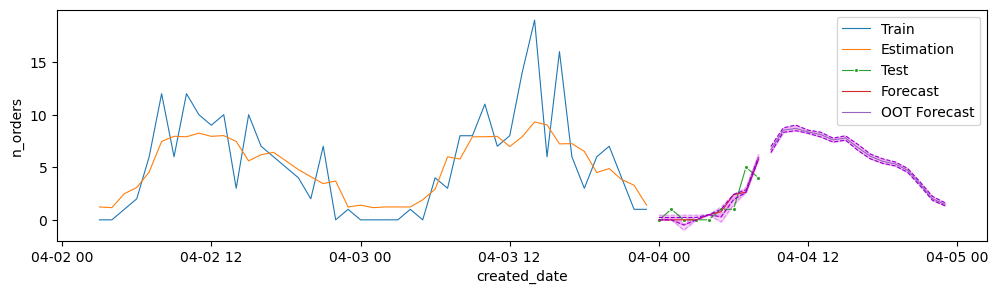

account_id: 5f5ed10c-7792-4080-970c-b11398e3f58f
sales_channel_id: 15
price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 0.000
train MAE:  0.000
test RMSE: 0.000
test MAE:  0.000


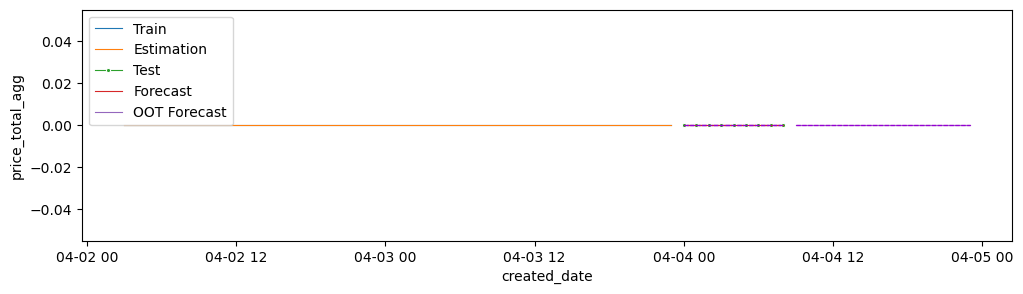

n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 0.000
train MAE:  0.000
test RMSE: 0.000
test MAE:  0.000


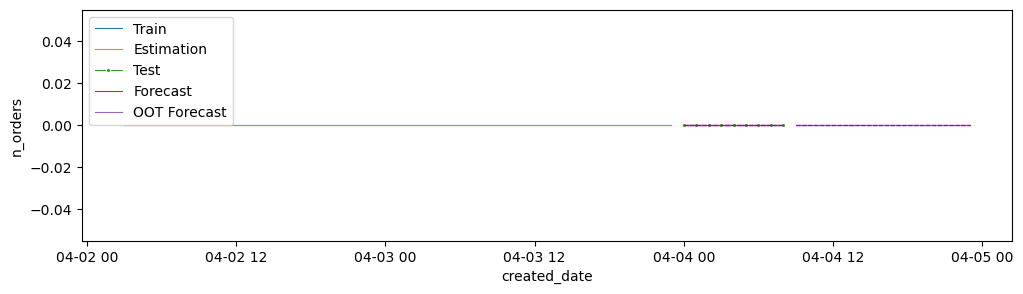

account_id: f9129295-bb08-4330-b60c-9f0beadda521
sales_channel_id: 38
price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 5695.968
train MAE:  4347.320
test RMSE: 3254.039
test MAE:  2470.663


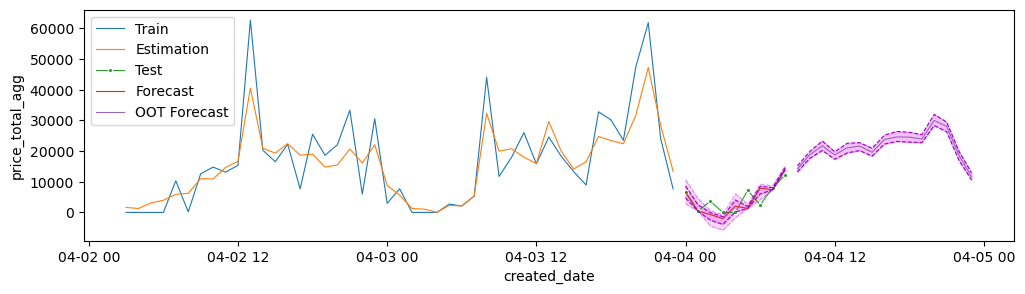

n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 3.252
train MAE:  2.333
test RMSE: 0.793
test MAE:  0.571


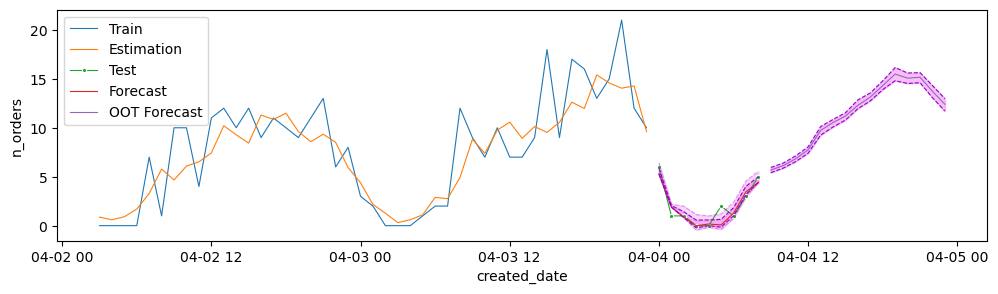

account_id: 5f5ed10c-7792-4080-970c-b11398e3f58f
sales_channel_id: 21
price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 0.000
train MAE:  0.000
test RMSE: 0.000
test MAE:  0.000


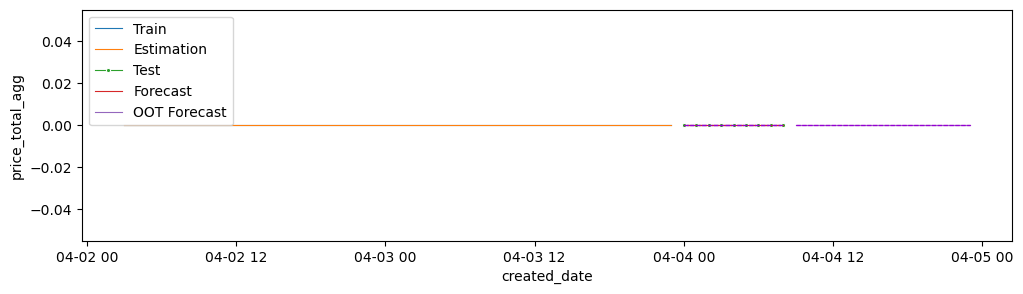

n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 0.000
train MAE:  0.000
test RMSE: 0.000
test MAE:  0.000


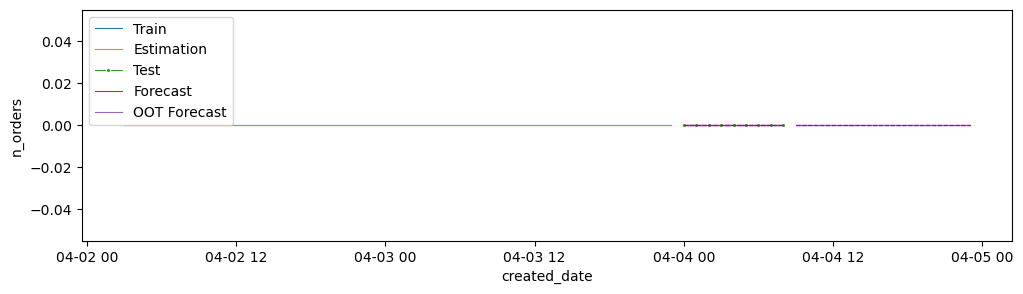

account_id: 775dcad4-0733-4c22-8dbd-cd3ce344e891
sales_channel_id: 1
price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 87.559
train MAE:  40.976
test RMSE: 60.991
test MAE:  23.943


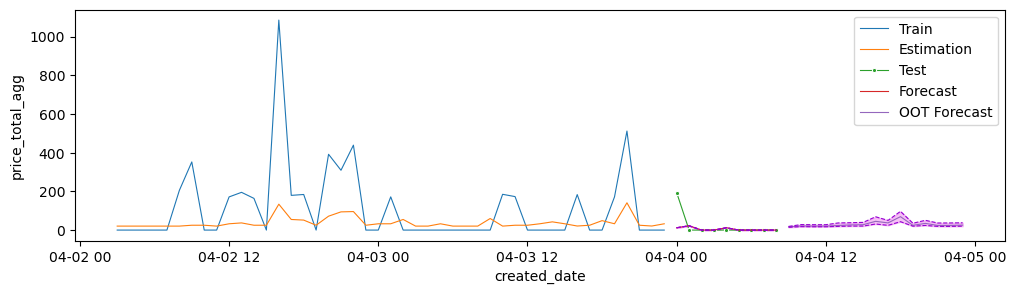

n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 0.302
train MAE:  0.154
test RMSE: 0.317
test MAE:  0.116


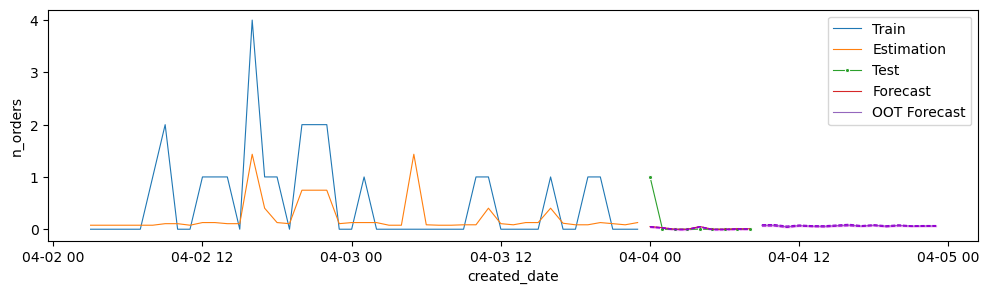

account_id: f9129295-bb08-4330-b60c-9f0beadda521
sales_channel_id: 16
price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 15503.947
train MAE:  11374.681
test RMSE: 8749.725
test MAE:  6243.794


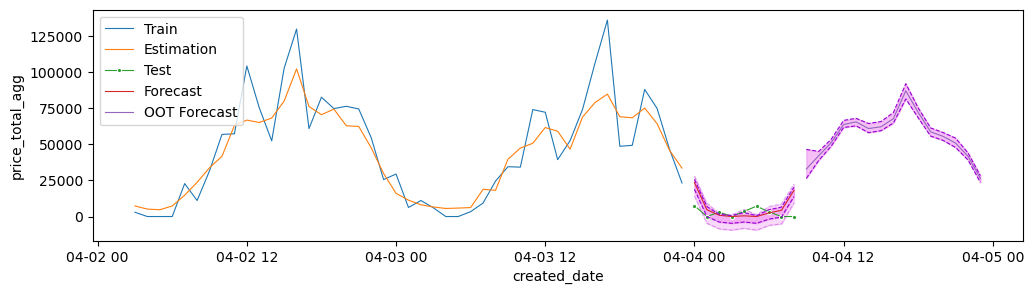

n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 4.381
train MAE:  3.095
test RMSE: 2.566
test MAE:  1.582


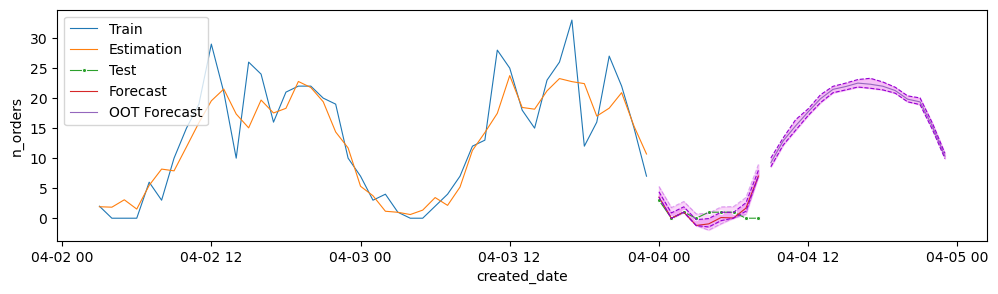

account_id: 23797b7c-9df5-45e7-89cd-548bbb7bd98f
sales_channel_id: 1
price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 83086.720
train MAE:  20909.264
test RMSE: 18699.203
test MAE:  12466.135


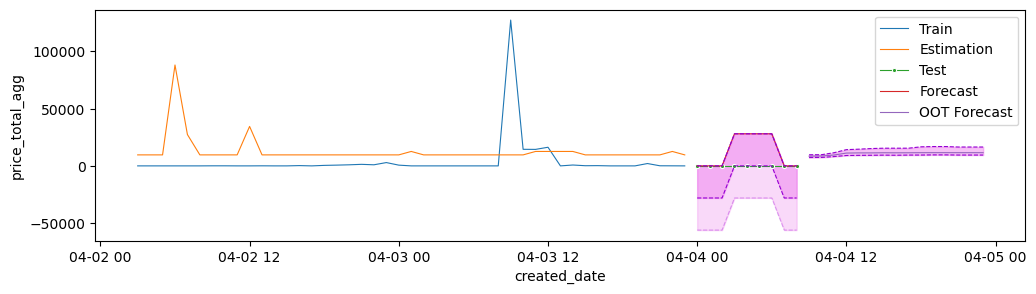

n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 1.978
train MAE:  1.040
test RMSE: 0.027
test MAE:  0.023


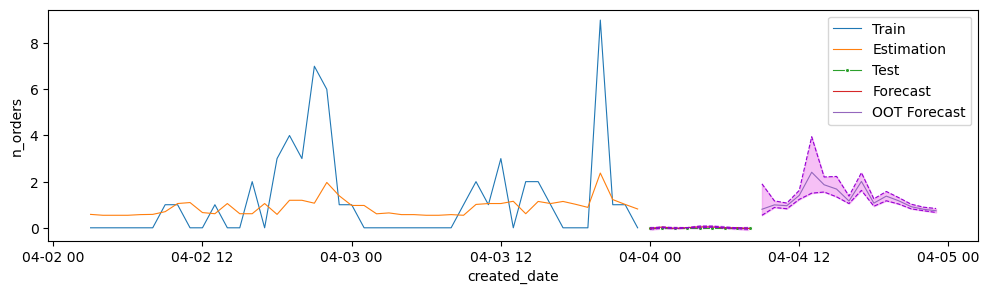

account_id: adc6fb62-09e7-44fd-a619-f787ecfd140b
sales_channel_id: 1
price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 464.253
train MAE:  305.911
test RMSE: 56.219
test MAE:  31.809


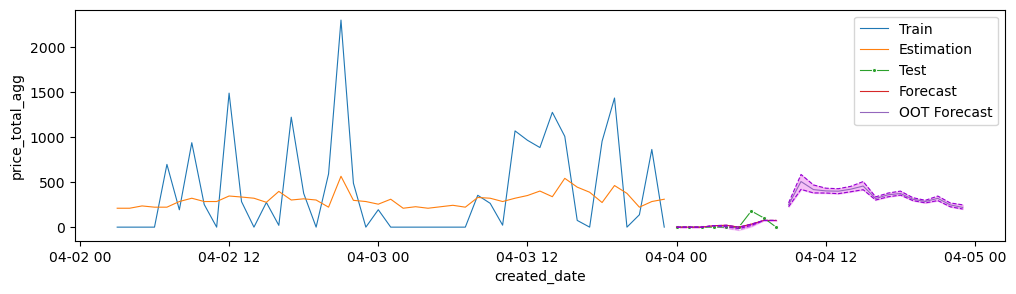

n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 1.331
train MAE:  1.021
test RMSE: 0.404
test MAE:  0.264


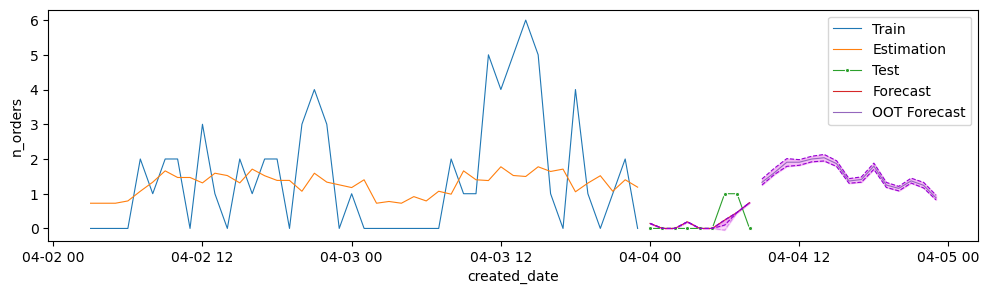

account_id: 8fa00df1-38eb-426f-81a6-1185983e14cb
sales_channel_id: 1
price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 219.006
train MAE:  57.105
test RMSE: 0.000
test MAE:  0.000


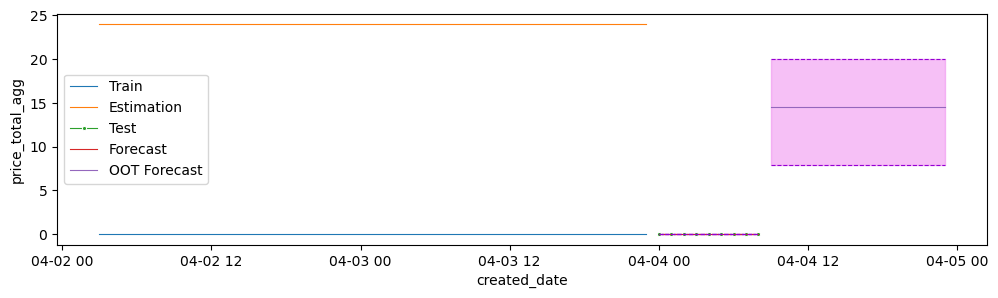

n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 4.813
train MAE:  1.195
test RMSE: 0.000
test MAE:  0.000


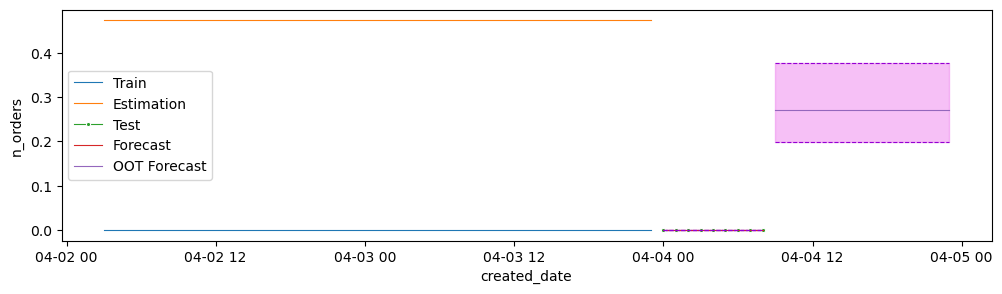

account_id: f9129295-bb08-4330-b60c-9f0beadda521
sales_channel_id: 18
price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 9666.146
train MAE:  7411.663
test RMSE: 6664.902
test MAE:  5155.213


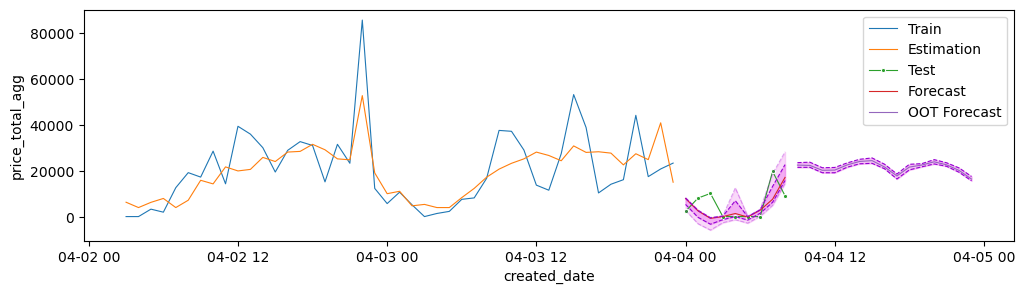

n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 3.052
train MAE:  2.281
test RMSE: 2.963
test MAE:  2.244


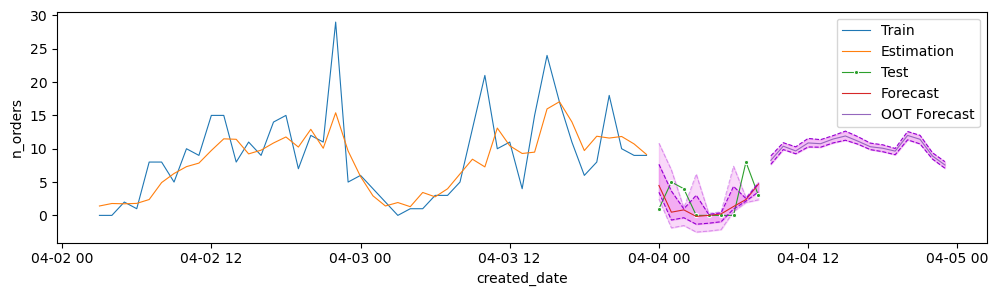

account_id: 6cd2fa8a-5bac-4cc0-b4df-bd2c7d29e71b
sales_channel_id: 1
price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 186.504
train MAE:  128.827
test RMSE: 73.866
test MAE:  38.341


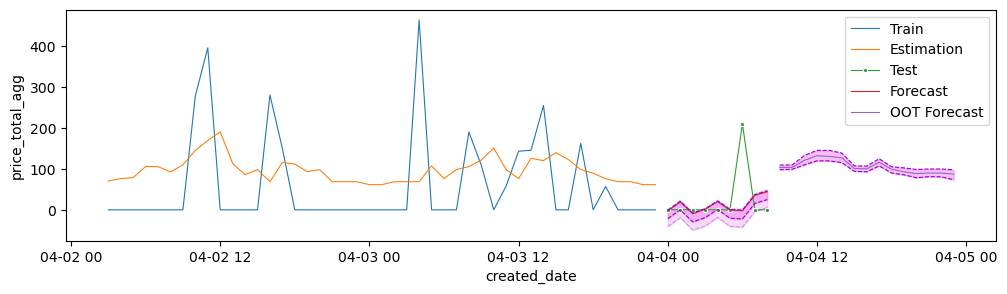

n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 0.789
train MAE:  0.577
test RMSE: 0.329
test MAE:  0.189


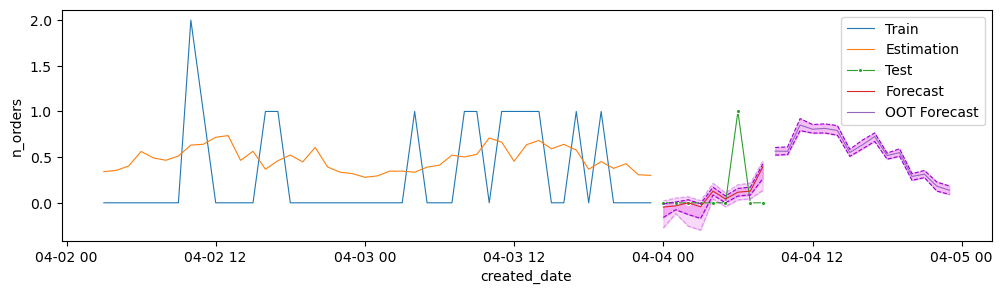

account_id: b009c05b-326e-4ebe-988c-8d2229ec3a4c
sales_channel_id: 1
price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 363.997
train MAE:  211.995
test RMSE: 399.320
test MAE:  266.757


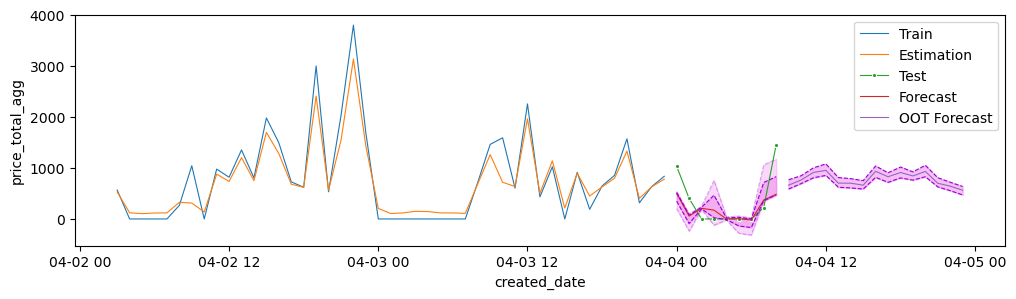

n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 1.490
train MAE:  1.094
test RMSE: 0.428
test MAE:  0.296


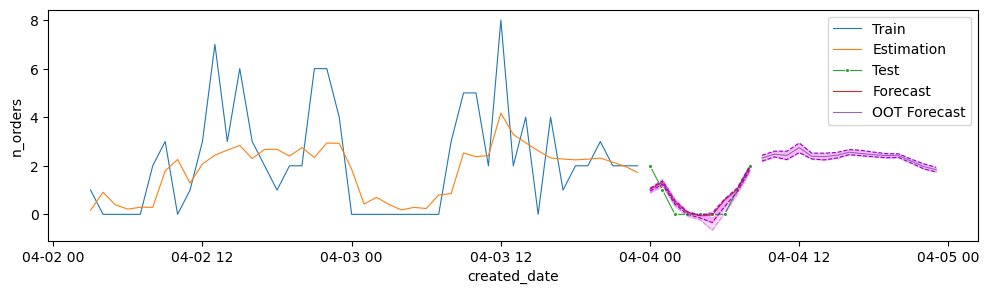

account_id: 22fde42e-45d7-46cd-9d6f-3a4dbabbc579
sales_channel_id: 1
price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 162.188
train MAE:  75.529
test RMSE: 334.784
test MAE:  120.402


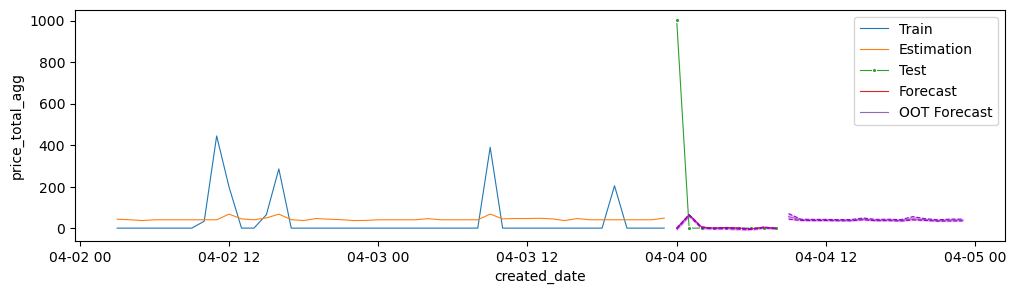

n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 0.389
train MAE:  0.233
test RMSE: 0.334
test MAE:  0.122


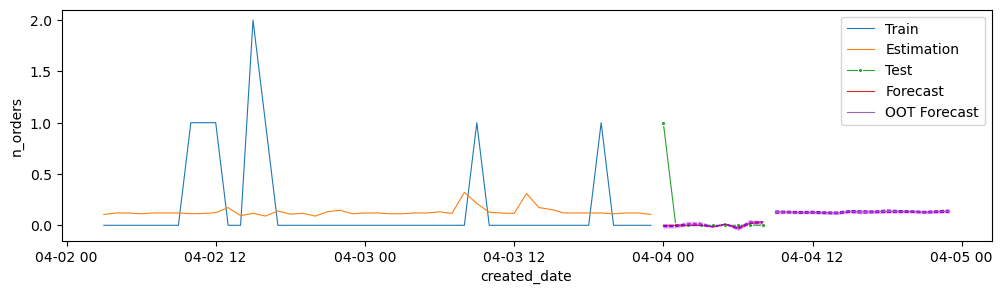

account_id: adc6fb62-09e7-44fd-a619-f787ecfd140b
sales_channel_id: 2
price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 274.987
train MAE:  111.710
test RMSE: 399.685
test MAE:  289.965


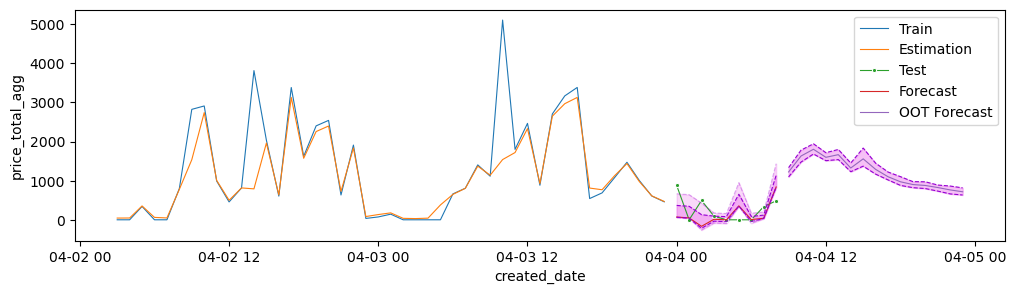

n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 1.752
train MAE:  1.285
test RMSE: 0.833
test MAE:  0.714


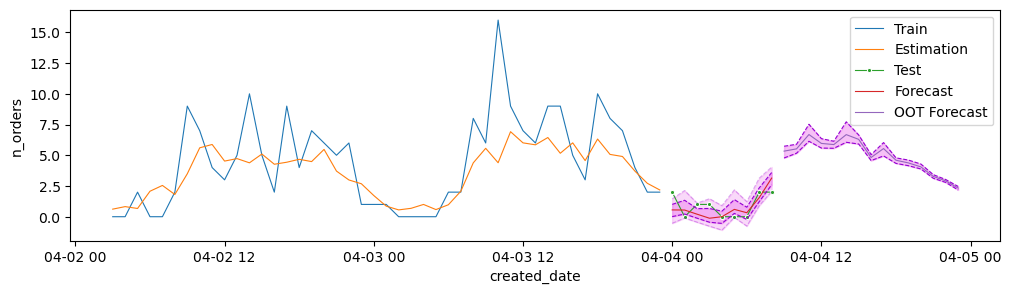

account_id: 6276b87c-ebb2-11ed-a05b-0242ac120003
sales_channel_id: 8
price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 369.385
train MAE:  238.277
test RMSE: 61.160
test MAE:  37.545


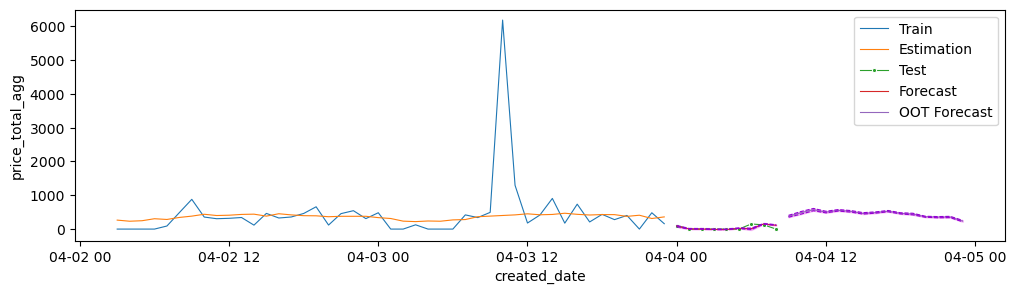

n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 3.005
train MAE:  1.570
test RMSE: 0.855
test MAE:  0.560


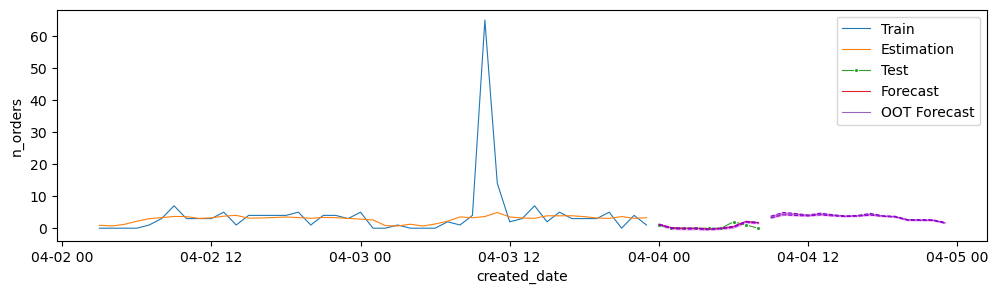

account_id: 5f5ed10c-7792-4080-970c-b11398e3f58f
sales_channel_id: 2
price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 0.000
train MAE:  0.000
test RMSE: 0.000
test MAE:  0.000


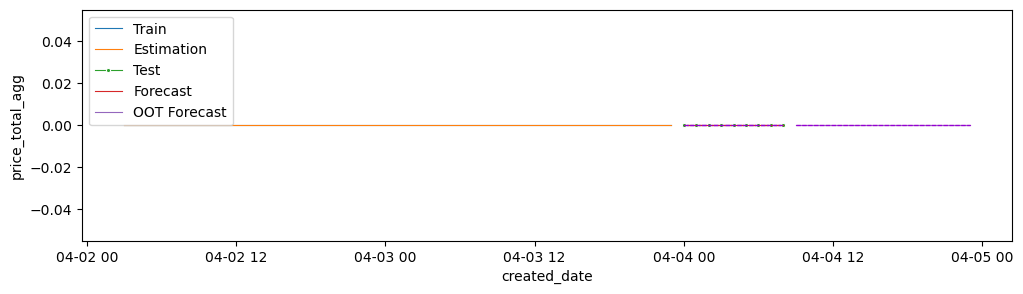

n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 0.000
train MAE:  0.000
test RMSE: 0.000
test MAE:  0.000


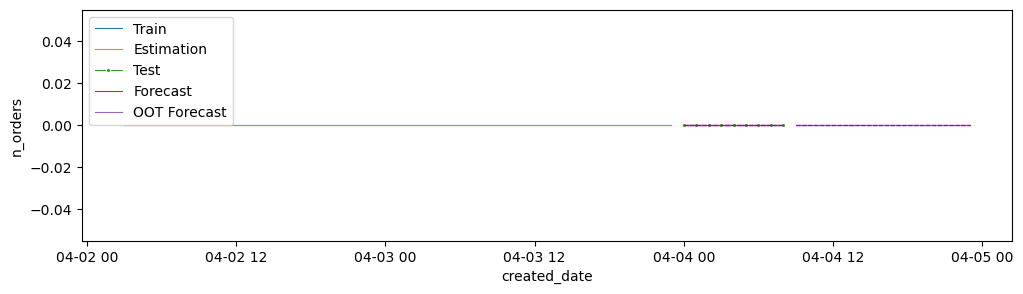

account_id: 4f1c8b04-eb4b-4887-8c69-a096f0fda3ab
sales_channel_id: 1
price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 939.845
train MAE:  677.231
test RMSE: 623.561
test MAE:  384.391


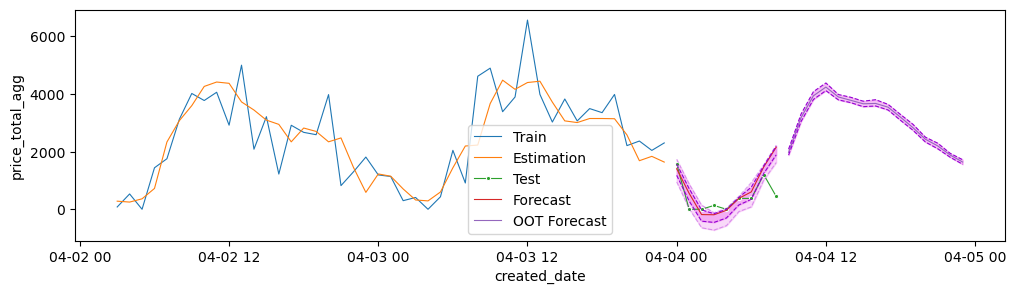

n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 4.309
train MAE:  3.105
test RMSE: 1.925
test MAE:  1.259


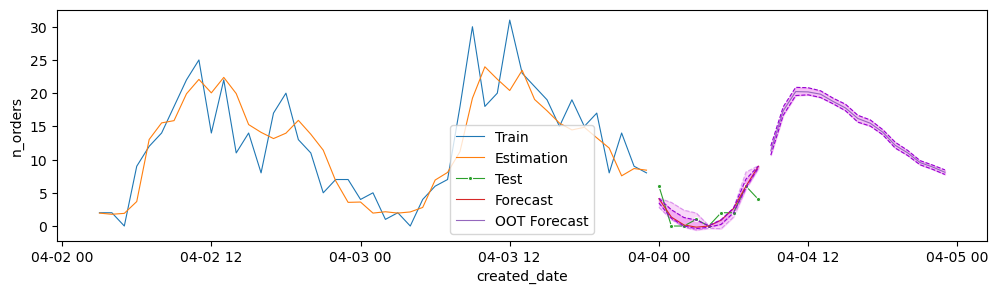

account_id: 05d9cc3a-decc-4fa2-b4e8-b44eef40e3b6
sales_channel_id: 1
price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 3825.703
train MAE:  1723.751
test RMSE: 248.254
test MAE:  129.552


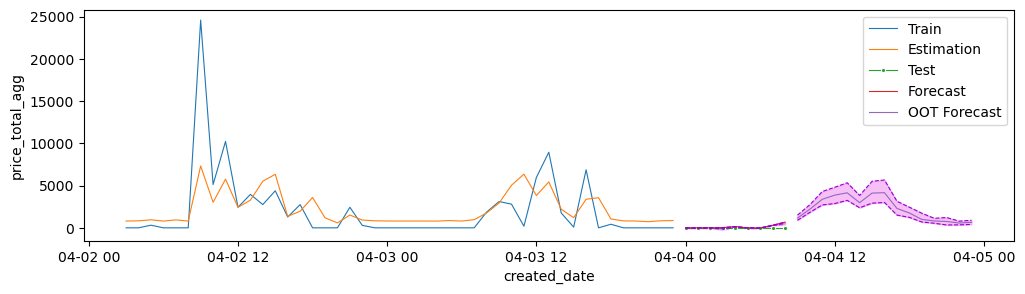

n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 0.532
train MAE:  0.322
test RMSE: 0.707
test MAE:  0.420


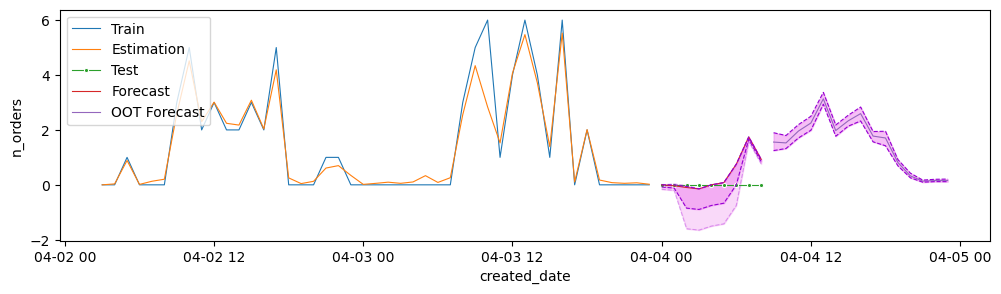

account_id: f9129295-bb08-4330-b60c-9f0beadda521
sales_channel_id: 17
price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 12063.332
train MAE:  9225.669
test RMSE: 2913.516
test MAE:  2452.210


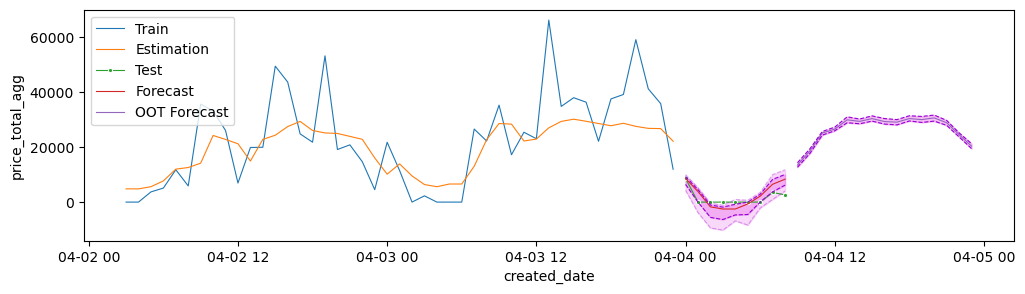

n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 3.221
train MAE:  2.432
test RMSE: 0.962
test MAE:  0.695


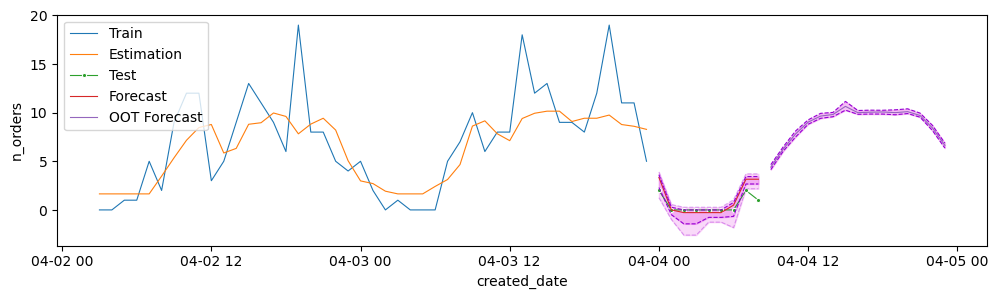

account_id: 3dc15e4b-b60d-4c49-aae8-97cf9664af51
sales_channel_id: 1
price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 128.744
train MAE:  49.667
test RMSE: 4.425
test MAE:  2.350


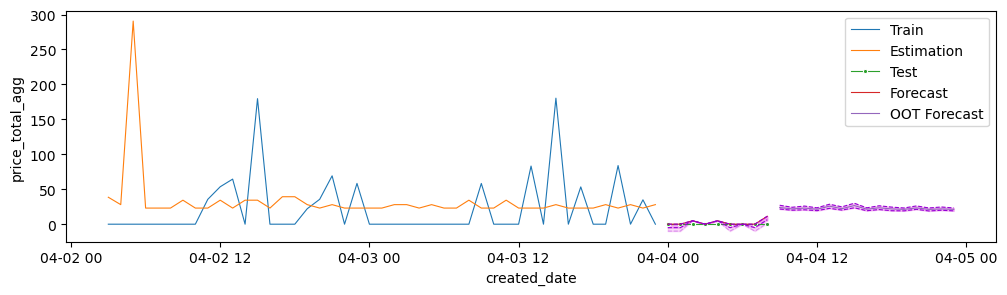

n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 2.238
train MAE:  0.563
test RMSE: 0.067
test MAE:  0.032


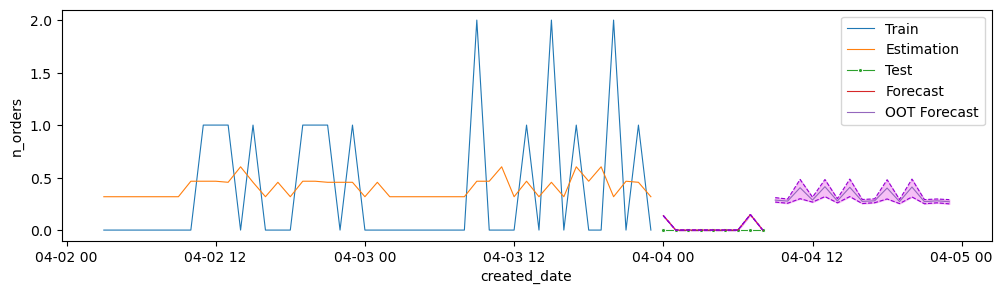

account_id: 74abffac-6542-4eff-8eae-cc85463a5d02
sales_channel_id: 3
price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 0.000
train MAE:  0.000
test RMSE: 0.000
test MAE:  0.000


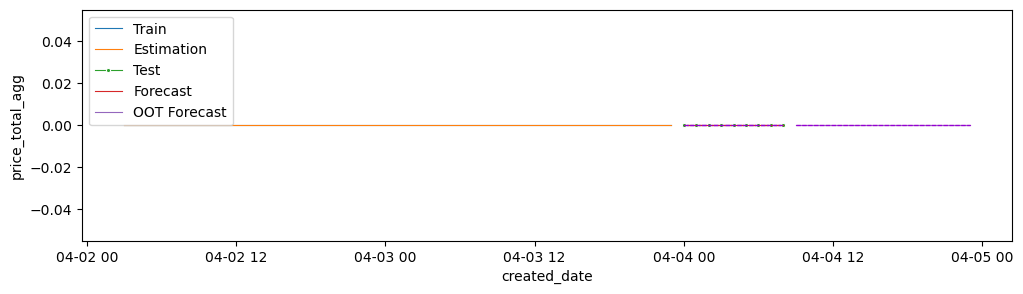

n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 0.000
train MAE:  0.000
test RMSE: 0.000
test MAE:  0.000


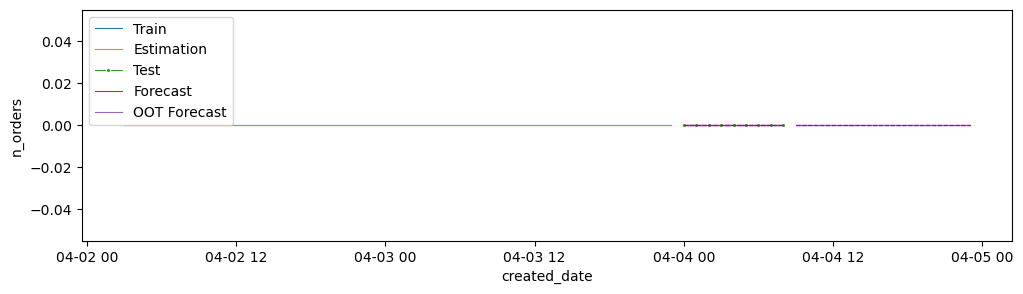

account_id: 423a069b-27b8-44ed-9ef3-ca3cf9470970
sales_channel_id: 1
price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 3101.984
train MAE:  1003.662
test RMSE: 10156.368
test MAE:  7156.550


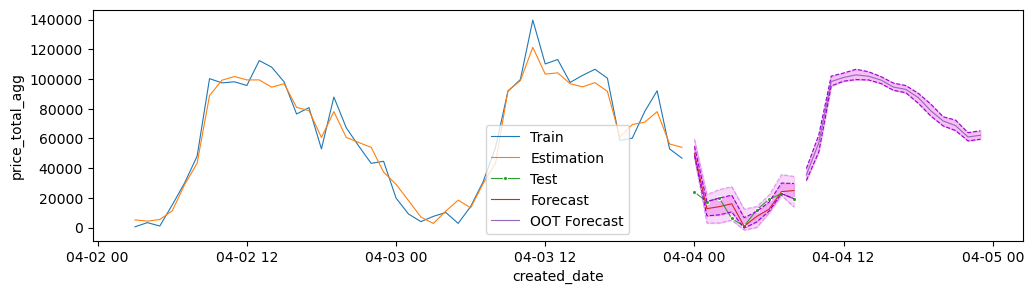

n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 8.519
train MAE:  3.120
test RMSE: 38.166
test MAE:  24.715


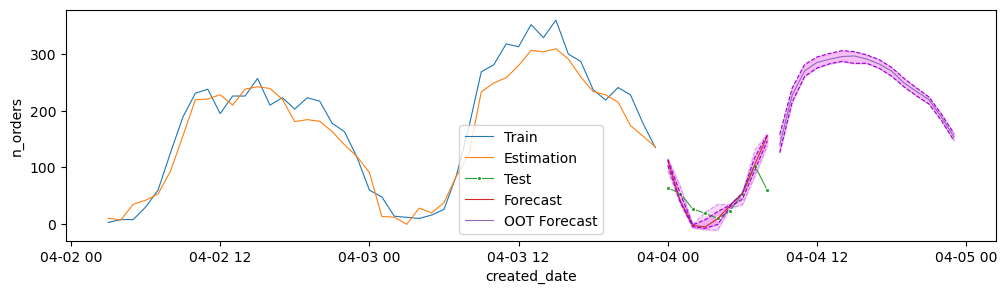

account_id: 5f5ed10c-7792-4080-970c-b11398e3f58f
sales_channel_id: 12
price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 0.000
train MAE:  0.000
test RMSE: 0.000
test MAE:  0.000


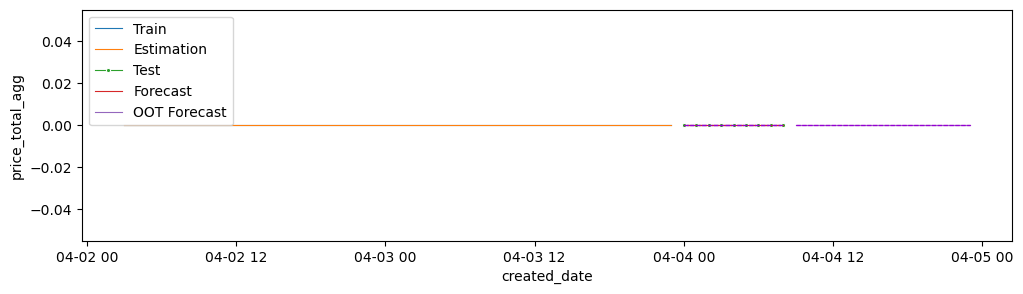

n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 0.000
train MAE:  0.000
test RMSE: 0.000
test MAE:  0.000


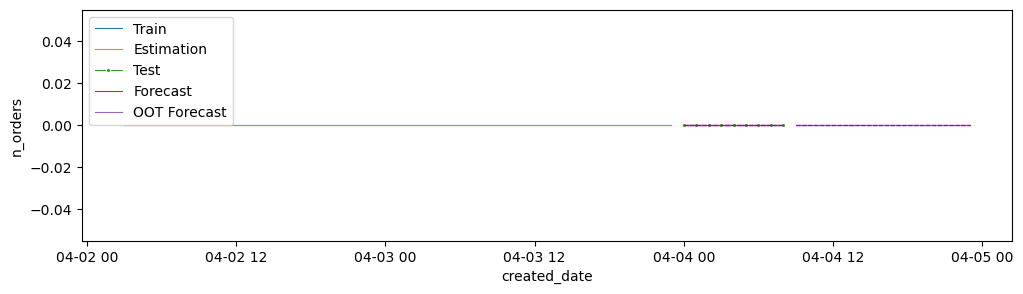

account_id: 0ad2f65b-ee0e-4d50-93e2-84b76282325f
sales_channel_id: 1
price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 4891.509
train MAE:  3460.949
test RMSE: 1287.443
test MAE:  818.543


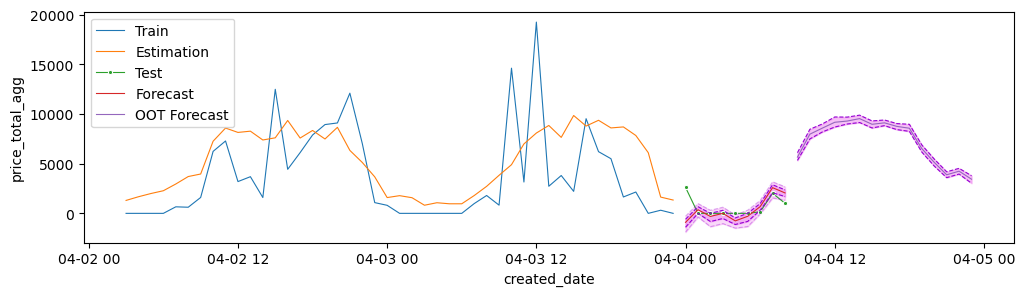

n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 2.426
train MAE:  1.787
test RMSE: 0.476
test MAE:  0.359


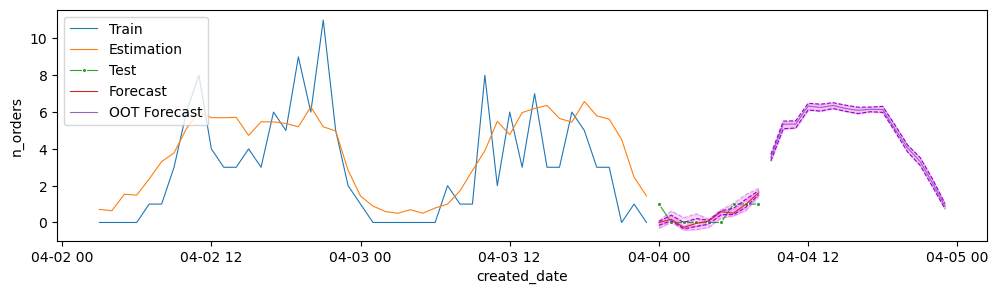

account_id: b8c6ac4b-2999-40f4-ad33-17649fb2f0aa
sales_channel_id: 17
price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 875.293
train MAE:  470.607
test RMSE: 979.449
test MAE:  445.080


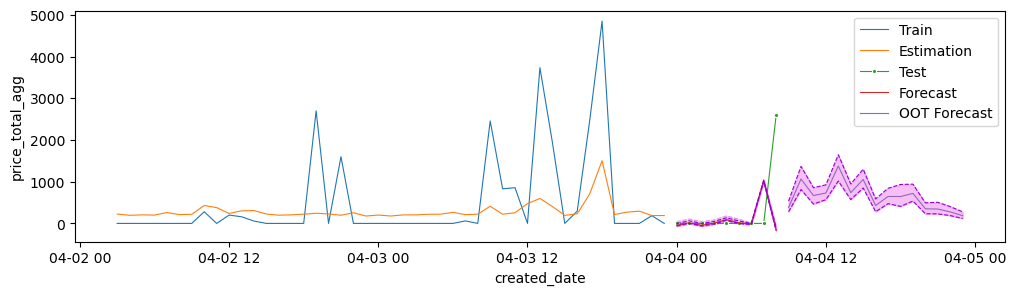

n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 0.541
train MAE:  0.389
test RMSE: 0.293
test MAE:  0.143


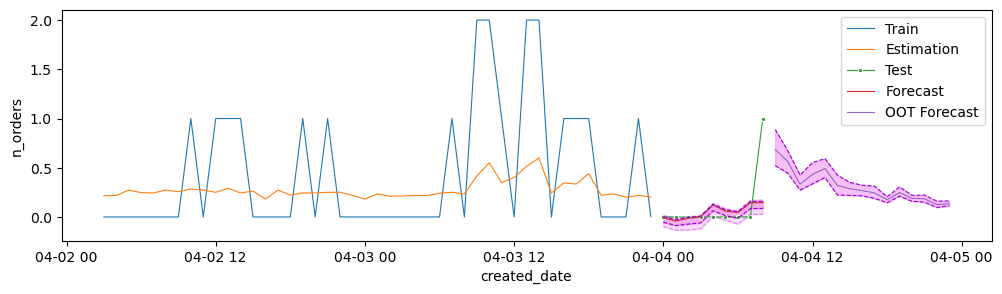

account_id: 423a069b-27b8-44ed-9ef3-ca3cf9470970
sales_channel_id: 2
price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 3603.793
train MAE:  1143.491
test RMSE: 17710.660
test MAE:  12657.793


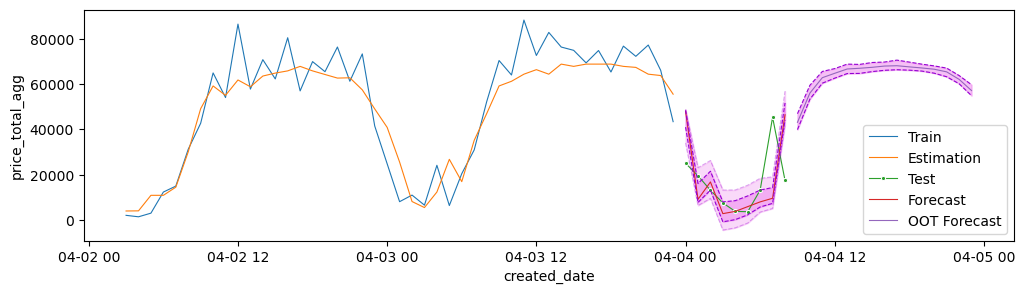

n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 7.553
train MAE:  2.370
test RMSE: 45.870
test MAE:  29.594


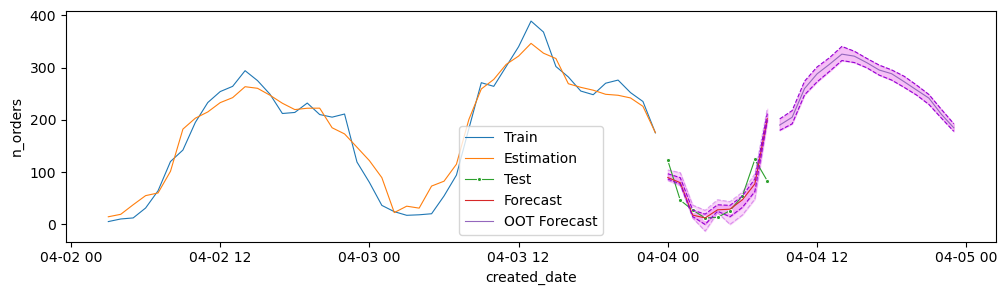

account_id: 6276b87c-ebb2-11ed-a05b-0242ac120003
sales_channel_id: 9
price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 216.448
train MAE:  164.526
test RMSE: 108.865
test MAE:  94.634


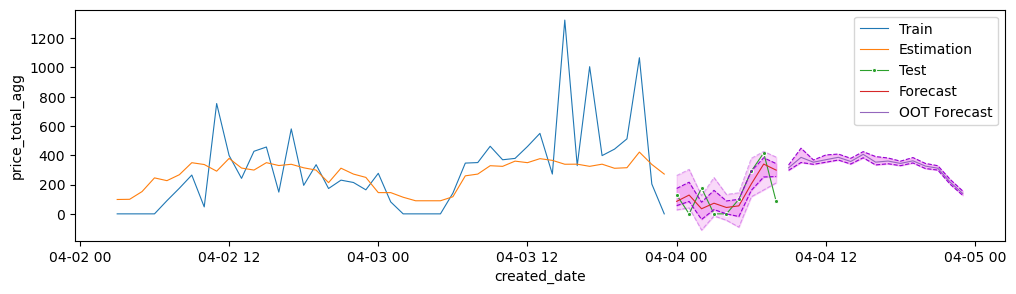

n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 1.502
train MAE:  1.180
test RMSE: 0.948
test MAE:  0.754


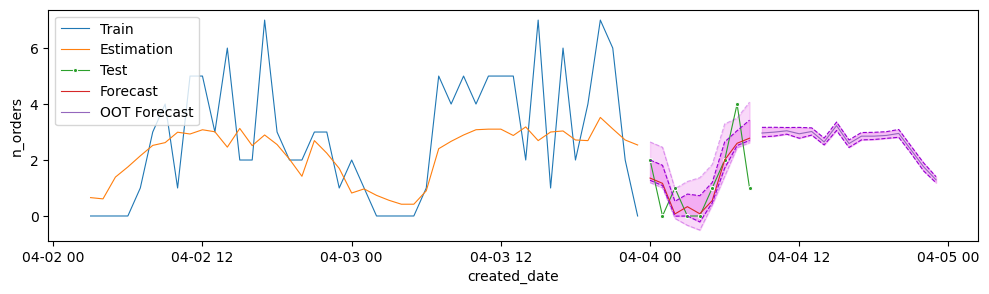

account_id: 173e2b27-8bc6-44d1-b581-a1913d6b1894
sales_channel_id: 11
price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 0.000
train MAE:  0.000
test RMSE: 0.000
test MAE:  0.000


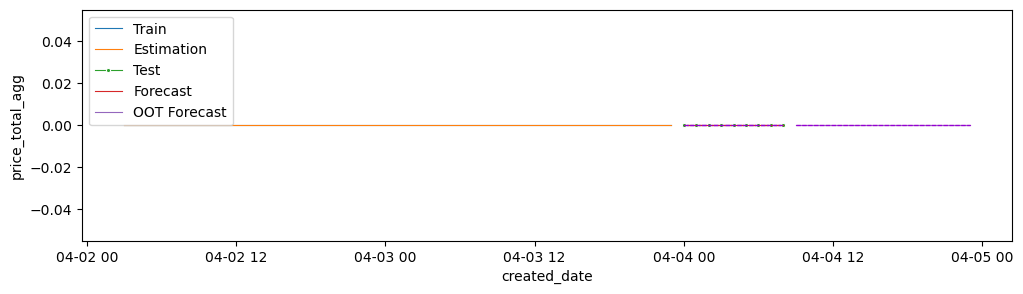

n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 0.000
train MAE:  0.000
test RMSE: 0.000
test MAE:  0.000


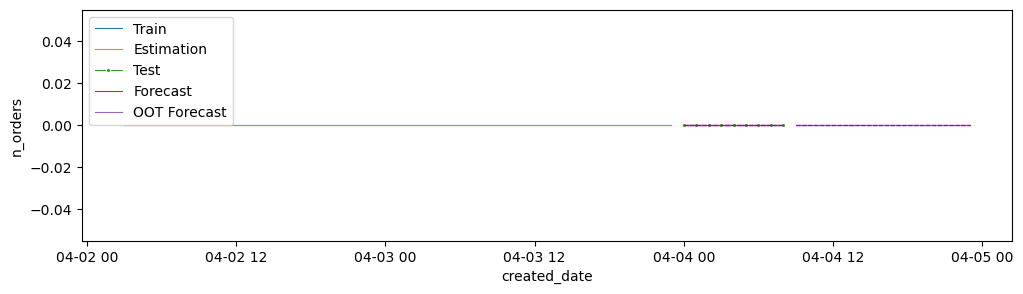

account_id: aabe992c-cfad-4049-b5df-36c41f900a67
sales_channel_id: 1
price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 251.914
train MAE:  137.725
test RMSE: 41.112
test MAE:  28.301


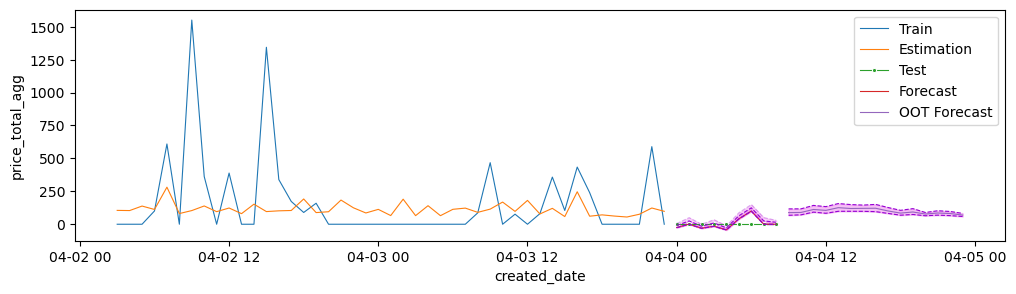

n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 0.558
train MAE:  0.449
test RMSE: 0.083
test MAE:  0.055


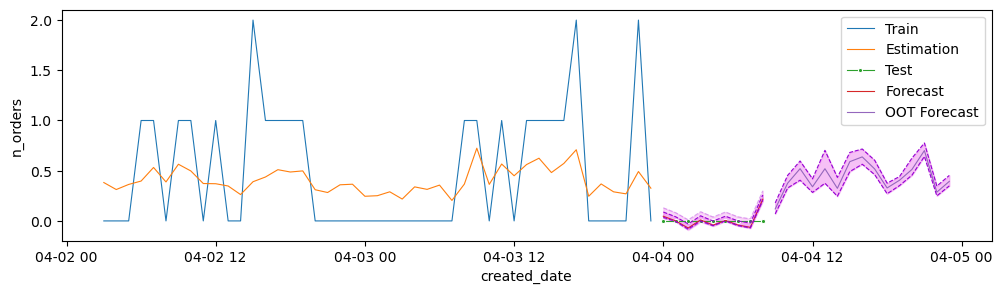

account_id: 9d1296ca-9e4f-4840-b7b5-e12172acab78
sales_channel_id: 1
price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 528.159
train MAE:  259.862
test RMSE: 177.100
test MAE:  59.033


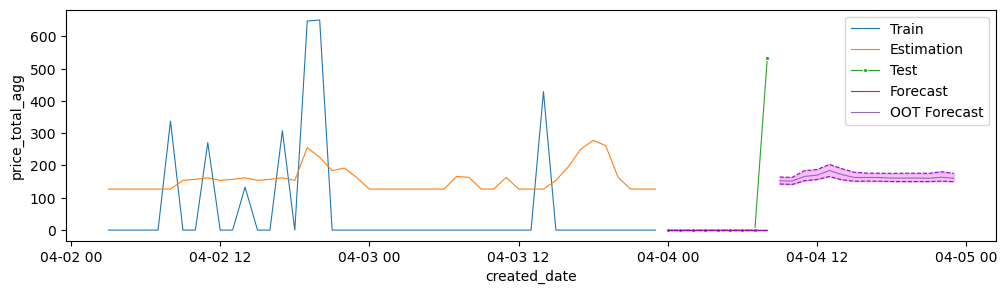

n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 0.606
train MAE:  0.458
test RMSE: 0.337
test MAE:  0.131


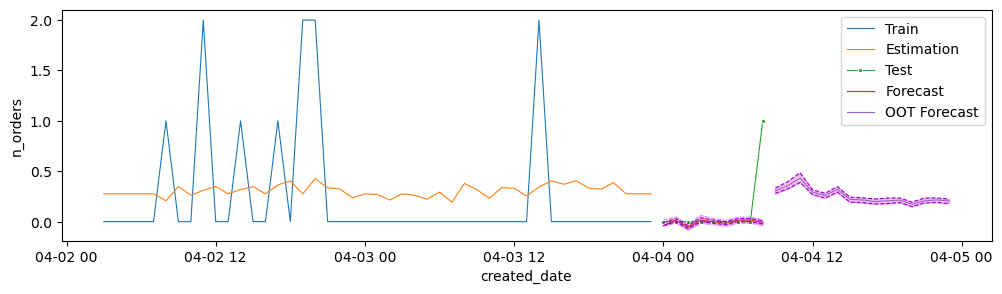

KeyboardInterrupt: 

In [ ]:
id_pairs = list(zip(df['account_id'], df['sales_channel_id']))
# id_pairs = list(zip(df_filtered['account_id'], df_filtered['sales_channel_id']))
summary_dict = {}
forecast_dict = {}
weights_chan = {}
for coverage in [n*10**-1 for n in range(1, 10)]:
    for account_id, sales_channel_id in id_pairs:
        
        if (account_id, str(sales_channel_id)) in res_forecast:
            continue
        
        print(f'account_id: {account_id}')
        print(f'sales_channel_id: {sales_channel_id}')

        summary_dict[(account_id, sales_channel_id)] = {}
        
        if sales_channel_id == 'ALL':
            cond = (sales['account_id'] == account_id) & \
                (sales['status'].notna())
        else:
            cond = (sales['account_id'] == account_id) & \
                (sales['sales_channel_id'] == sales_channel_id) & \
                (sales['status'].notna())

        df_client = sales[cond].drop(['account_id', 'sales_channel_id'], axis=1)
        df_client['created_date'] = pd.to_datetime(df_client['created_date'], format='%Y-%m-%d %H:%M:%S.%f %z')
        df_client = df_client.sort_values('created_date').reset_index(drop=True)
        df_client['created_date'] = df_client['created_date'].dt.strftime("%Y-%m-%d %H:00:00").reset_index(drop=True)

        df_client_mod = df_client.groupby('created_date').agg(price_total_agg=('price_total', 'sum'), n_orders=('created_date', 'count'))
        df_client_mod.index = pd.to_datetime(df_client_mod.index, format='%Y-%m-%d %H:00:00')

        end_date = pd.to_datetime(END_DATE, format='%Y-%m-%d %H:%M:%S')
        start_date = end_date - relativedelta(months=LOOKBACK)
        date_index = pd.Series(pd.date_range(start=start_date, end=end_date, freq='h', name='created_date'))
        df_client_mod = pd.merge(date_index, df_client_mod, how='left', on='created_date').set_index('created_date')

        oot_date_index = pd.Series(df_oot.index, name='created_date')
        combined_date_index = pd.concat([date_index, oot_date_index], axis=0)
        df_client_mod = pd.merge(combined_date_index, df_client_mod, how='left', on='created_date').set_index('created_date')

        forecast_dict[account_id] = {} if account_id not in forecast_dict else forecast_dict[account_id]
        forecast_dict[account_id][sales_channel_id] = {}
        
        weights_chan[account_id] = {} if account_id not in weights_chan else weights_chan[account_id]

        for n, col in enumerate(['price_total_agg', 'n_orders']):
            print(col)
            
            summary_dict[(account_id, sales_channel_id)][f'dataset_{n}'] = {}
            summary_dict[(account_id, sales_channel_id)][f'dataset_{n}']['name'] = col
            
            forecast_dict[account_id][sales_channel_id][f'dataset_{n}'] = {}
            
            df = df_client_mod[col]
            
            df.fillna(0, inplace=True)
            
            lags = [df.shift(l).rename(f'lag_{l}') for l in range(1, 25)]
            df_lag = pd.concat([df, pd.concat(lags, axis=1)], axis=1).dropna().asfreq('h')
            
            df = df_lag.loc[df_lag.index <= END_DATE].copy()
            df_train = df_lag.loc[df_lag.index < START_DATE].copy()
            df_test = df_lag.loc[(df_lag.index >= START_DATE) & (df_lag.index <= END_DATE)].copy()
            df_oot = df_lag.loc[df_lag.index > END_DATE].copy()
            
            if col == 'n_orders':
                weights_chan[account_id][sales_channel_id] = df['n_orders'].median()

            X, y = df.iloc[:, 1:], df.iloc[:, 0]
            X_train, y_train = df_train.iloc[:, 1:], df_train.iloc[:, 0]
            X_test, y_test = df_test.iloc[:, 1:], df_test.iloc[:, 0]
            X_oot = df_oot.iloc[:, 1:]
            
            gscv = GridSearchCV(GradientBoostingRegressor(random_state=42, n_iter_no_change=3),
                                param_grid={'max_depth': [1, 2, 4, 8, 16],
                                            'subsample': [0.2, 0.4, 0.6, 0.8, 1],
                                            'max_features': ['sqrt', 'log2', None]},
                                scoring='neg_root_mean_squared_error',
                                cv=TimeSeriesSplit(),
                                n_jobs=-1,
                                verbose=1)
            gscv.fit(X_train, y_train)
            gb = gscv.best_estimator_
            
            estimations = pd.Series(gb.predict(X_train), index=X_train.index)
            
            gb_forecast = pd.Series(gb.predict(X_test), index=X_test.index)
            
            forecast_lower, forecast, forecast_upper = calculate_prediction_intervals(y_test, gb_forecast, confidence_level=coverage, n_bootstrap=300)
            
            forecast_dict[account_id][sales_channel_id][f'dataset_{n}']['forecast'] = forecast
            forecast_dict[account_id][sales_channel_id][f'dataset_{n}']['forecast_lower'] = forecast_lower
            forecast_dict[account_id][sales_channel_id][f'dataset_{n}']['forecast_upper'] = forecast_upper
            
            forecast_dict[account_id][sales_channel_id][f'dataset_{n}']['oot_forecast'] = []
            forecast_dict[account_id][sales_channel_id][f'dataset_{n}']['oot_forecast_lower'] = []
            forecast_dict[account_id][sales_channel_id][f'dataset_{n}']['oot_forecast_upper'] = []
            
            oot_gscv = GridSearchCV(GradientBoostingRegressor(random_state=42, n_iter_no_change=3),
                                    param_grid={'max_depth': [1, 2, 4, 8, 16],
                                                'subsample': [0.2, 0.4, 0.6, 0.8, 1],
                                                'max_features': ['sqrt', 'log2', None]},
                                    scoring='neg_root_mean_squared_error',
                                    cv=TimeSeriesSplit(),
                                    n_jobs=-1,
                                    verbose=1)
            oot_gscv.fit(X, y)
            oot_gb = gscv.best_estimator_
            
            oot_forecast_ls = []
            oot_forecast_lower_ls = []
            oot_forecast_upper_ls = []
            for i in range(len(X_oot)):
                x_oot = X_oot.iloc[i].to_frame().T
                
                x_oot_forecast = oot_gb.predict(x_oot)[0]
                oot_forecast_ls.append(x_oot_forecast)
                
                for j, k in list(zip(range(i+1, len(X_oot)), range(len(X_oot)-i-1))):
                    X_oot.iloc[j, k] = x_oot_forecast
            
            oot_forecast_lower, oot_forecast, oot_forecast_upper = calculate_oot_prediction_intervals(df, X_oot, oot_gb, target_column=col, confidence_level=coverage, n_bootstrap=300)
            
            forecast_dict[account_id][sales_channel_id][f'dataset_{n}']['oot_forecast'] = oot_forecast
            forecast_dict[account_id][sales_channel_id][f'dataset_{n}']['oot_forecast_lower'] = oot_forecast_lower
            forecast_dict[account_id][sales_channel_id][f'dataset_{n}']['oot_forecast_upper'] = oot_forecast_upper
            
            train_pred = estimations
            train_mae = mean_absolute_error(df_train.iloc[:, 0], train_pred)
            train_rmse = root_mean_squared_error(df_train.iloc[:, 0], train_pred)

            print(f"train RMSE: {train_rmse:.3f}")
            print(f"train MAE:  {train_mae:.3f}")
            
            test_pred = forecast
            test_mae = mean_absolute_error(df_test.iloc[:, 0], test_pred)
            test_rmse = root_mean_squared_error(df_test.iloc[:, 0], test_pred)

            print(f"test RMSE: {test_rmse:.3f}")
            print(f"test MAE:  {test_mae:.3f}")
            
            summary_dict[(account_id, sales_channel_id)][f'dataset_{n}']['train RMSE'] = train_rmse
            summary_dict[(account_id, sales_channel_id)][f'dataset_{n}']['test RMSE'] = test_rmse
            summary_dict[(account_id, sales_channel_id)][f'dataset_{n}']['train MAE'] = train_mae
            summary_dict[(account_id, sales_channel_id)][f'dataset_{n}']['test MAE'] = test_mae
            
            plt.figure(figsize=(12, 3))
            sns.lineplot(y_train.iloc[-5*TEST_SIZE:], lw=0.8, label='Train')
            sns.lineplot(estimations.iloc[-5*TEST_SIZE:], lw=0.8, label='Estimation')
            sns.lineplot(y_test, lw=0.8, label='Test', marker='o', markersize=3)
            sns.lineplot(forecast, lw=0.8, label='Forecast')
            sns.lineplot(forecast_lower, c='darkviolet', linestyle='--', lw=0.8)
            sns.lineplot(forecast_upper, c='darkviolet', linestyle='--', lw=0.8)
            sns.lineplot(2*forecast_lower-forecast, c='darkviolet', alpha=0.3, linestyle='--', lw=0.8)
            sns.lineplot(2*forecast_upper-forecast, c='darkviolet', alpha=0.3, linestyle='--', lw=0.8)
            sns.lineplot(oot_forecast, lw=0.8, label='OOT Forecast')
            sns.lineplot(oot_forecast_lower, c='darkviolet', linestyle='--', lw=0.8)
            sns.lineplot(oot_forecast_upper, c='darkviolet', linestyle='--', lw=0.8)
            plt.fill_between(x=forecast.index[-TEST_SIZE:],
                                y1=forecast_lower,
                                y2=forecast_upper,
                                color='violet',
                                alpha=0.5)
            plt.fill_between(x=forecast.index[-TEST_SIZE:],
                                y1=2*forecast_lower-forecast,
                                y2=2*forecast_upper-forecast,
                                color='violet',
                                alpha=0.3)
            plt.fill_between(x=oot_forecast.index,
                                y1=oot_forecast_lower,
                                y2=oot_forecast_upper,
                                color='violet',
                                alpha=0.5)
            plt.legend()
            plt.savefig(f'plots/machine_learning/forecast_{account_id}_{sales_channel_id}_{col}_ml.png')
            plt.show();
            
        

        # with open(f'sql/machine_learning/forecast_{account_id}_{sales_channel_id}_ml.sql', 'w') as output_file:
        #     pt_forecast_lower = forecast_dict[account_id][sales_channel_id]['dataset_0']['forecast_lower']
        #     pt_forecast_upper = forecast_dict[account_id][sales_channel_id]['dataset_0']['forecast_upper']
        #     pt_forecast = forecast_dict[account_id][sales_channel_id]['dataset_0']['forecast']
            
        #     no_forecast_lower = forecast_dict[account_id][sales_channel_id]['dataset_1']['forecast_lower']
        #     no_forecast_upper = forecast_dict[account_id][sales_channel_id]['dataset_1']['forecast_upper']
        #     no_forecast = forecast_dict[account_id][sales_channel_id]['dataset_1']['forecast']
        #     for i in range(len(df_test)):
        #         start_time = df_test.index[i]
        #         end_time = start_time + pd.Timedelta(hours=1)
        #         output_file.write(
        #             f"""
        #             INSERT INTO forecast (id, created, modified, platform, store_name, "start", "end",
        #                                   channel, seller, account_id, organization_id, store_id, minutes_interval,
        #                                   model, orders_high, orders_low, orders_mean, sales_high, sales_low, sales_mean)
        #             VALUES (gen_random_uuid(), now(), now(), 1, (select vtexid from vtex_account where id = '{account_id}'::uuid), '{start_time}', '{end_time}',
        #                     {sales_channel_id}, 'ALL', '{account_id}'::uuid, (select organizationid from vtex_account where id = '{account_id}'::uuid), NULL, 60, 'GradientBoosting',
        #                     {no_forecast_upper.iloc[i]}, {no_forecast_lower.iloc[i]}, {no_forecast.iloc[i]},
        #                     {pt_forecast_upper.iloc[i]}, {pt_forecast_lower.iloc[i]}, {pt_forecast.iloc[i]});
        #             """
        #             )
            
        #     pt_oot_forecast_lower = forecast_dict[account_id][sales_channel_id]['dataset_0']['oot_forecast_lower']
        #     pt_oot_forecast_upper = forecast_dict[account_id][sales_channel_id]['dataset_0']['oot_forecast_upper']
        #     pt_oot_forecast = forecast_dict[account_id][sales_channel_id]['dataset_0']['oot_forecast']
            
        #     no_oot_forecast_lower = forecast_dict[account_id][sales_channel_id]['dataset_1']['oot_forecast_lower']
        #     no_oot_forecast_upper = forecast_dict[account_id][sales_channel_id]['dataset_1']['oot_forecast_upper']
        #     no_oot_forecast = forecast_dict[account_id][sales_channel_id]['dataset_1']['oot_forecast']
        #     for i in range(len(df_oot)):
        #         start_time = df_oot.index[i]
        #         end_time = start_time + pd.Timedelta(hours=1)
        #         output_file.write(
        #             f"""
        #             INSERT INTO forecast (id, created, modified, platform, store_name, "start", "end",
        #                                   channel, seller, account_id, organization_id, store_id, minutes_interval,
        #                                   model, orders_high, orders_low, orders_mean, sales_high, sales_low, sales_mean)
        #             VALUES (gen_random_uuid(), now(), now(), 1, (select vtexid from vtex_account where id = '{account_id}'::uuid), '{start_time}', '{end_time}',
        #                     {sales_channel_id}, 'ALL', '{account_id}'::uuid, (select organizationid from vtex_account where id = '{account_id}'::uuid), NULL, 60, 'GradientBoosting',
        #                     {no_oot_forecast_upper.iloc[i]}, {no_oot_forecast_lower.iloc[i]}, {no_oot_forecast.iloc[i]},
        #                     {pt_oot_forecast_upper.iloc[i]}, {pt_oot_forecast_lower.iloc[i]}, {pt_oot_forecast.iloc[i]});
        #             """     
        #             )
                
        pt_forecast_lower = forecast_dict[account_id][sales_channel_id]['dataset_0']['forecast_lower']
        pt_forecast_upper = forecast_dict[account_id][sales_channel_id]['dataset_0']['forecast_upper']
        pt_forecast = forecast_dict[account_id][sales_channel_id]['dataset_0']['forecast']
        
        no_forecast_lower = forecast_dict[account_id][sales_channel_id]['dataset_1']['forecast_lower']
        no_forecast_upper = forecast_dict[account_id][sales_channel_id]['dataset_1']['forecast_upper']
        no_forecast = forecast_dict[account_id][sales_channel_id]['dataset_1']['forecast']
        for i in range(len(df_test)):
            start_time = df_test.index[i]
            end_time = start_time + pd.Timedelta(hours=1)
            price_insert = \
                f"""
                INSERT INTO public.forecast (id, created, modified, platform, store_name, "start", "end",
                                            channel, seller, account_id, organization_id, store_id, minutes_interval,
                                            model, orders_high, orders_low, orders_mean, sales_high, sales_low, sales_mean)
                VALUES (gen_random_uuid(), now(), now(), 1, '{account_id}'::uuid, '{start_time}', '{end_time}',
                        '{sales_channel_id}', 'ALL', '{account_id}'::uuid, '{account_id}'::uuid, NULL, 60, 'GradientBoosting_{100*coverage}',
                        {no_forecast_upper.iloc[i]}, {no_forecast_lower.iloc[i]}, {no_forecast.iloc[i]},
                        {pt_forecast_upper.iloc[i]}, {pt_forecast_lower.iloc[i]}, {pt_forecast.iloc[i]});
                """
            cursor.execute(price_insert)
        
        pt_oot_forecast_lower = forecast_dict[account_id][sales_channel_id]['dataset_0']['oot_forecast_lower']
        pt_oot_forecast_upper = forecast_dict[account_id][sales_channel_id]['dataset_0']['oot_forecast_upper']
        pt_oot_forecast = forecast_dict[account_id][sales_channel_id]['dataset_0']['oot_forecast']
        
        no_oot_forecast_lower = forecast_dict[account_id][sales_channel_id]['dataset_1']['oot_forecast_lower']
        no_oot_forecast_upper = forecast_dict[account_id][sales_channel_id]['dataset_1']['oot_forecast_upper']
        no_oot_forecast = forecast_dict[account_id][sales_channel_id]['dataset_1']['oot_forecast']
        for i in range(len(df_oot)):
            start_time = df_oot.index[i]
            end_time = start_time + pd.Timedelta(hours=1)
            order_insert = \
                f"""
                INSERT INTO public.forecast (id, created, modified, platform, store_name, "start", "end",
                                            channel, seller, account_id, organization_id, store_id, minutes_interval,
                                            model, orders_high, orders_low, orders_mean, sales_high, sales_low, sales_mean)
                VALUES (gen_random_uuid(), now(), now(), 1, '{account_id}'::uuid, '{start_time}', '{end_time}',
                        '{sales_channel_id}', 'ALL', '{account_id}'::uuid, '{account_id}'::uuid, NULL, 60, 'GradientBoosting_{100*coverage}',
                        {no_oot_forecast_upper.iloc[i]}, {no_oot_forecast_lower.iloc[i]}, {no_oot_forecast.iloc[i]},
                        {pt_oot_forecast_upper.iloc[i]}, {pt_oot_forecast_lower.iloc[i]}, {pt_oot_forecast.iloc[i]});
                """
            cursor.execute(order_insert)
            
        cursor.execute('commit;')

In [ ]:
# cursor.close()